# Lesson 2 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/skripiy/ida-practice-3d/blob/main/practice/2/2-homework-results.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
the function must return. Replace `raise NotImplementedError` with your
implementation; the cell after it asserts the behaviour.

**A failing assert is information, not a grade.** Read it, fix the
function, re-run.

The written questions are marked and they carry the real learning
objective. Each asks you to **run something both ways and explain the
difference**, using numbers you produced. One sentence will not be enough.

Every function you need is demonstrated in `2-practice.ipynb`, and each task
names the section. You should not need any other documentation.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`2-homework-results.ipynb`, and commit it to your fork under
`practice/2/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seaborn", sns.__version__)

python 3.14.6 | pandas 3.0.3 | seaborn 0.13.2


In [2]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


In [3]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
titanic = pd.read_csv("../datasets/titanic.csv")
wine = pd.read_csv("../datasets/wine.csv")
bikes = pd.read_csv("../datasets/bike_sharing_hourly.csv")

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


## 2. Task 1 — A missingness report

Mechanical.

*see Practice 2 §5.1*

In [4]:
def missing_report(frame):
    """Return a DataFrame describing the missing values of `frame`.

    One row per column that has at least one missing value. Columns with
    no missing values are excluded entirely.

    Two columns, in this order:
        'missing'  the count of missing values, an integer
        'percent'  the percentage of rows missing, 0-100, rounded to 2 dp

    Sorted by 'missing', descending. The index is the original column name.
    """
    counts = frame.isna().sum()
    counts = counts[counts > 0].sort_values(ascending=False)
    return pd.DataFrame(
        {
            "missing": counts.astype(int),
            "percent": (100.0 * counts / len(frame)).round(2),
        }
    )

In [5]:
_report = missing_report(titanic)

assert list(_report.columns) == ["missing", "percent"], f"columns wrong: {list(_report.columns)}"
assert len(_report) == 3, f"Titanic has three columns with gaps, you reported {len(_report)}"
assert list(_report.index) == ["Cabin", "Age", "Embarked"], \
    f"wrong columns or wrong order: {list(_report.index)}"
assert _report.loc["Cabin", "missing"] == 687
assert _report.loc["Age", "missing"] == 177
assert _report.loc["Embarked", "missing"] == 2
assert np.isclose(_report.loc["Age", "percent"], 19.87, atol=0.01), \
    f"percent should be 100 * 177/891 = 19.87, got {_report.loc['Age', 'percent']}"

# a frame with no gaps produces an empty report, not an error
assert len(missing_report(wine)) == 0, "wine.csv has no missing values"

print(_report)
print("\nTask 1 passed.")

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200

Task 1 passed.


## 3. Task 2 — Label against position

Mechanical, and the trap is real. After a sort, `.loc` and `.iloc` answer
different questions.

*see Practice 2 §4*

In [6]:
def first_and_labelled(frame, sort_column, label):
    """Sort `frame` by `sort_column` descending, then return a tuple:

        (top_row, labelled_row)

    top_row       the row now in FIRST POSITION, as a Series
    labelled_row  the row whose INDEX LABEL equals `label`, as a Series

    Do not reset the index. Both must come from the sorted frame.
    """
    ordered = frame.sort_values(sort_column, ascending=False)
    # .iloc answers "where is it now", .loc answers "which row is it".
    return ordered.iloc[0], ordered.loc[label]

In [7]:
_top, _labelled = first_and_labelled(titanic, "Fare", 0)

assert isinstance(_top, pd.Series) and isinstance(_labelled, pd.Series)
assert np.isclose(_top["Fare"], 512.3292), \
    f"the highest fare is 512.3292, you returned {_top['Fare']}"
assert _labelled["Name"] == "Braund, Mr. Owen Harris", \
    f"label 0 is Braund, you returned {_labelled['Name']}"
assert np.isclose(_labelled["Fare"], 7.25)
assert _top["Name"] != _labelled["Name"], \
    "position 0 and label 0 must be different passengers after sorting"

print("position 0 after sorting:", _top["Name"], "| fare", round(_top["Fare"], 2))
print("label 0 after sorting   :", _labelled["Name"], "| fare", round(_labelled["Fare"], 2))
print("\nTask 2 passed.")

position 0 after sorting: Cardeza, Mr. Thomas Drake Martinez | fare 512.33
label 0 after sorting   : Braund, Mr. Owen Harris | fare 7.25

Task 2 passed.


## 4. Task 3 — Group-wise imputation, without the chained-assignment bug

Applied. Fill missing ages with the median of the passenger's
`(Pclass, Sex)` group, and do it without triggering a
`SettingWithCopyWarning`.

*see Practice 2 §4.2, §5.4 and §6.3*

In [8]:
def fill_age_by_group(frame):
    """Return a COPY of `frame` with missing 'Age' filled by the median age
    of the passenger's (Pclass, Sex) group.

    The argument must not be modified.
    The returned frame must have no missing 'Age'.
    Use groupby(...).transform(...), not a loop, and not agg.
    """
    out = frame.copy()
    # transform broadcasts each group's median back onto every row of that
    # group, so the result is already aligned to `out` and fillna can take
    # it directly. Assigning a whole column on a frame we own keeps this
    # off the chained-assignment path entirely.
    group_median = out.groupby(["Pclass", "Sex"])["Age"].transform("median")
    out["Age"] = out["Age"].fillna(group_median)
    return out

In [9]:
import warnings

_before_missing = int(titanic["Age"].isna().sum())

with warnings.catch_warnings():
    warnings.simplefilter("error")          # any pandas warning becomes an exception
    _filled = fill_age_by_group(titanic)

assert int(titanic["Age"].isna().sum()) == _before_missing, "the argument was modified"
assert int(_filled["Age"].isna().sum()) == 0, "some ages are still missing"
assert len(_filled) == len(titanic), "rows were added or lost"

# The ages that were already present must be untouched.
_present = titanic["Age"].notna()
assert np.allclose(_filled.loc[_present, "Age"], titanic.loc[_present, "Age"]), \
    "existing ages were altered"

# A filled passenger must receive their own group's median, not the global one.
_a_gap = titanic.index[titanic["Age"].isna()][0]
_pclass, _sex = titanic.loc[_a_gap, "Pclass"], titanic.loc[_a_gap, "Sex"]
_expected = titanic[(titanic["Pclass"] == _pclass) & (titanic["Sex"] == _sex)]["Age"].median()
assert np.isclose(_filled.loc[_a_gap, "Age"], _expected), \
    f"passenger {_a_gap} got {_filled.loc[_a_gap, 'Age']}, expected group median {_expected}"

print(f"filled {_before_missing} ages; std went from "
      f"{titanic['Age'].std():.4f} to {_filled['Age'].std():.4f}")
print("Task 3 passed.")

filled 177 ages; std went from 14.5265 to 13.3044
Task 3 passed.


## 5. Task 4 — Four imputations, four distributions

Applied.

*see Practice 2 §5.4*

In [10]:
def compare_imputations(frame, column="Age"):
    """Return a DataFrame comparing four ways of handling missing values.

    Index, exactly these four labels in this order:
        'dropna', 'mean', 'median', 'group_median'

    Columns, in this order: 'n', 'mean', 'median', 'std'
        n       number of non-missing values after the strategy is applied
        mean    the mean of the resulting values
        median  the median
        std     the standard deviation (pandas default, ddof=1)

    'group_median' fills with the median of the (Pclass, Sex) group.
    """
    values = frame[column]
    group_median = frame.groupby(["Pclass", "Sex"])[column].transform("median")

    variants = {
        "dropna": values.dropna(),
        "mean": values.fillna(values.mean()),
        "median": values.fillna(values.median()),
        "group_median": values.fillna(group_median),
    }

    rows = {
        name: {
            "n": int(v.notna().sum()),
            "mean": float(v.mean()),
            "median": float(v.median()),
            "std": float(v.std()),
        }
        for name, v in variants.items()
    }
    return pd.DataFrame(rows).T[["n", "mean", "median", "std"]]

In [11]:
_comparison = compare_imputations(titanic)

assert list(_comparison.index) == ["dropna", "mean", "median", "group_median"]
assert list(_comparison.columns) == ["n", "mean", "median", "std"]
assert _comparison.loc["dropna", "n"] == 714, "dropna keeps the 714 recorded ages"
assert _comparison.loc["mean", "n"] == 891, "filling keeps all 891 rows"

# Filling with the mean preserves the mean exactly and shrinks the spread.
assert np.isclose(_comparison.loc["mean", "mean"], titanic["Age"].mean()), \
    "filling with the mean must leave the mean unchanged"
assert _comparison.loc["mean", "std"] < _comparison.loc["dropna", "std"], \
    "stacking 177 rows on one value must reduce the standard deviation"

# The group-wise fill distorts the spread less than a single constant does.
assert _comparison.loc["group_median", "std"] > _comparison.loc["mean", "std"], \
    "the group-wise fill should preserve more of the spread than a constant fill"

print(_comparison.round(4))
print("\nTask 4 passed.")

                    n    mean  median     std
dropna       714.0000 29.6991 28.0000 14.5265
mean         891.0000 29.6991 29.6991 13.0020
median       891.0000 29.3616 28.0000 13.0197
group_median 891.0000 29.1124 26.0000 13.3044

Task 4 passed.


### Question 1 — choosing an imputation

Using the table you just produced, and a histogram of each of the four
resulting distributions:

**(a)** Filling with the mean leaves the mean **exactly** unchanged and
still damages the data. What quantity did it damage, by how much, and why
does preserving the mean not make the fill harmless?

**(b)** Compare `dropna` with the three fills. Dropping loses 177 rows,
20 % of the data. Under what condition about *why* the values are missing
is dropping unbiased, and is that condition plausible for Titanic's `Age`?
Name the MCAR / MAR / MNAR category you think applies and give your
evidence.

**(c)** You must pick one strategy and defend it to a reviewer. Pick one
and write the defence in three sentences.

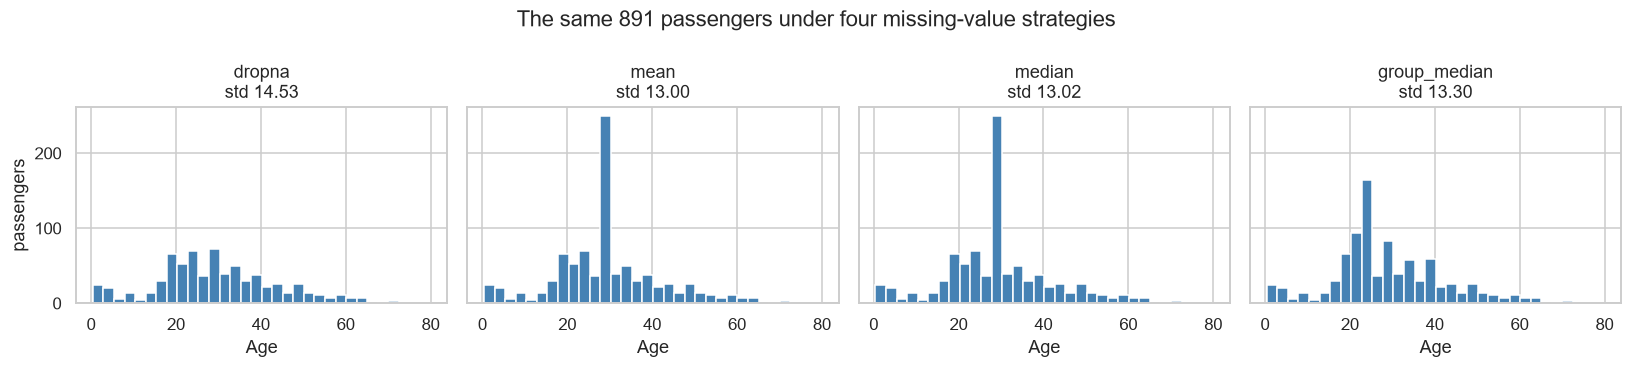

                    n    mean  median     std
dropna       714.0000 29.6991 28.0000 14.5265
mean         891.0000 29.6991 29.6991 13.0020
median       891.0000 29.3616 28.0000 13.0197
group_median 891.0000 29.1124 26.0000 13.3044

spread, against the 714 recorded ages:
  dropna        std 14.5265   ( +0.00%)
  mean          std 13.0020   (-10.49%)
  median        std 13.0197   (-10.37%)
  group_median  std 13.3044   ( -8.41%)

percent of Age missing, by class:
Pclass
1   13.8900
2    5.9800
3   27.7000
Name: age_missing, dtype: float64

percent of Age missing, by whether a cabin was recorded:
cabin_known
False   23.0000
True     9.3100
Name: age_missing, dtype: float64

percent of Age missing, by port of embarkation:
Embarked
C   22.6200
Q   63.6400
S   13.9800
Name: age_missing, dtype: float64

percent surviving, by whether Age is missing:
age_missing
False   40.6200
True    29.3800
Name: Survived, dtype: float64


In [12]:
_ages = titanic["Age"]
_group_median = titanic.groupby(["Pclass", "Sex"])["Age"].transform("median")

_variants = {
    "dropna": _ages.dropna(),
    "mean": _ages.fillna(_ages.mean()),
    "median": _ages.fillna(_ages.median()),
    "group_median": _ages.fillna(_group_median),
}

_fig, _axs = plt.subplots(1, 4, figsize=(15.0, 3.4), sharey=True, sharex=True)
for _ax, (_name, _values) in zip(_axs, _variants.items()):
    _ax.hist(_values, bins=32, color="steelblue", edgecolor="white")
    _ax.set_title(f"{_name}\nstd {_values.std():.2f}")
    _ax.set_xlabel("Age")
_axs[0].set_ylabel("passengers")
_fig.suptitle("The same 891 passengers under four missing-value strategies")
_fig.tight_layout()
plt.show()

print(_comparison.round(4))

_base_std = _variants["dropna"].std()
print("\nspread, against the 714 recorded ages:")
for _name, _values in _variants.items():
    print(f"  {_name:13s} std {_values.std():7.4f}"
          f"   ({100 * (_values.std() / _base_std - 1):+6.2f}%)")

# Is the missingness related to anything we can observe?
_flag = titanic.assign(age_missing=titanic["Age"].isna(),
                       cabin_known=titanic["Cabin"].notna())
print("\npercent of Age missing, by class:")
print((100 * _flag.groupby("Pclass")["age_missing"].mean()).round(2))
print("\npercent of Age missing, by whether a cabin was recorded:")
print((100 * _flag.groupby("cabin_known")["age_missing"].mean()).round(2))
print("\npercent of Age missing, by port of embarkation:")
print((100 * _flag.groupby("Embarked")["age_missing"].mean()).round(2))
print("\npercent surviving, by whether Age is missing:")
print((100 * _flag.groupby("age_missing")["Survived"].mean()).round(2))

**Answer:**

**(a) What the mean fill damaged.** The spread. The standard deviation of
`Age` falls from **14.5265** on the 714 recorded ages to **13.0020**, a
loss of **10.49 %**, and the median moves from 28.00 to 29.6991. The mean
survives by construction: adding 177 copies of the mean to a sample cannot
move the mean. That is exactly why preserving it is no defence — the fill
was never going to move the mean, so the mean staying put is not evidence
that anything was preserved. Every quantity computed from the *dispersion*
is now wrong in the direction that looks like extra confidence: a standard
error built on 891 rows of which 177 are a constant is too small, a
confidence interval built from it is too narrow, and the correlation of
`Age` with anything else is attenuated, because a fifth of the rows now
carry no information about `Age` while still counting as full observations.
The histogram shows the damage directly: a single bar of 177 passengers at
29.70 that corresponds to no passenger.

**(b) Dropping, and why the values are missing.** Dropping 177 rows is
unbiased only if the rows that vanish are a random sample of all rows —
MCAR, missingness independent of everything, observed or not. The data
says plainly that they are not:

| observed variable | share of `Age` missing |
|---|---|
| `Pclass` 1 / 2 / 3 | 13.89 % / 5.98 % / **27.70 %** |
| cabin recorded / not | 9.31 % / **23.00 %** |
| embarked C / Q / S | 22.62 % / **63.64 %** / 13.98 % |

Queenstown loses nearly two thirds of its ages and third class more than a
quarter. Missingness is therefore predictable from variables that are in
the table, which is **MAR**, not MCAR — so `dropna` does not remove a
random 20 %, it removes disproportionately third-class, Queenstown,
cabin-less passengers, and those are also the passengers who died
(survival is **29.38 %** among the missing-age rows against **40.62 %**
among the recorded ones). I cannot rule out MNAR — the ages may be absent
precisely because the passenger was anonymous and poor, which is a
statement about the unrecorded value itself — but MAR is what the data
supports and it is the weakest assumption that is sufficient.

**(c) The one I would defend.** I would use the **group median on
(Pclass, Sex), together with an explicit `Age_missing` indicator column**.
It keeps all 891 rows, which matters when the rows that would be dropped
are the ones carrying the outcome signal; it conditions on exactly the
observed variables that the missingness depends on, which is the condition
under which a fill is unbiased under MAR, and it preserves more of the
spread than any constant does (**13.3044** against 13.0020 for the mean and
13.0197 for the median). The indicator column is the part that makes the
defence honest: it hands the model the fact that the age was unknown, which
is itself predictive (29.38 % against 40.62 % survival), so the fill no
longer has to pretend the value was observed.

## 6. Task 5 — The IQR rule

Applied. Implement the rule behind a boxplot's whiskers.

*see Practice 2 §10.4*

In [13]:
def iqr_outliers(series, multiplier=1.5):
    """Flag the values of `series` outside the 1.5 x IQR fences.

    Q1 and Q3 are the 25th and 75th percentiles; IQR = Q3 - Q1.
    The fences are Q1 - multiplier*IQR and Q3 + multiplier*IQR.
    A value strictly outside either fence is an outlier.

    Missing values are never outliers.

    Return a dict with exactly these five keys:
        'q1', 'q3', 'lower', 'upper'   the four numbers, as floats
        'mask'  a boolean Series aligned to `series`, True where outlying
    """
    q1 = float(series.quantile(0.25))
    q3 = float(series.quantile(0.75))
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr

    # A comparison against NaN is False on both sides, so a missing value
    # falls out of the mask by itself; the fillna makes that explicit and
    # guarantees a bool dtype rather than object.
    mask = ((series < lower) | (series > upper)).fillna(False).astype(bool)

    return {
        "q1": q1,
        "q3": q3,
        "lower": float(lower),
        "upper": float(upper),
        "mask": mask,
    }

In [14]:
_fare = iqr_outliers(titanic["Fare"], multiplier=1.5)

assert set(_fare) == {"q1", "q3", "lower", "upper", "mask"}
assert np.isclose(_fare["q1"], 7.9104, atol=1e-3), f"Q1 wrong: {_fare['q1']}"
assert np.isclose(_fare["q3"], 31.0, atol=1e-6), f"Q3 wrong: {_fare['q3']}"
assert np.isclose(_fare["upper"], 65.6344, atol=1e-3), f"upper fence wrong: {_fare['upper']}"
assert _fare["mask"].dtype == bool
assert int(_fare["mask"].sum()) == 116, \
    f"the 1.5 x IQR rule flags 116 fares, you found {int(_fare['mask'].sum())}"

# A larger multiplier can never flag more points.
assert iqr_outliers(titanic["Fare"], 3.0)["mask"].sum() <= _fare["mask"].sum()

# Missing values must not be flagged.
_age_flags = iqr_outliers(titanic["Age"])["mask"]
assert not _age_flags[titanic["Age"].isna()].any(), "a missing value is not an outlier"
assert len(_age_flags) == len(titanic), "the mask must align to the input"

print(f"Fare: Q1 {_fare['q1']:.2f}, Q3 {_fare['q3']:.2f}, "
      f"fences [{_fare['lower']:.2f}, {_fare['upper']:.2f}], {int(_fare['mask'].sum())} flagged")
print("Task 5 passed.")

Fare: Q1 7.91, Q3 31.00, fences [-26.72, 65.63], 116 flagged
Task 5 passed.


### Question 2 — the multiplier, and two rules that disagree

**(a)** Run `iqr_outliers` on `Fare` at multipliers 1.0, 1.5, 3.0 and 5.0
and report the count at each. Then compute the 3σ count from Practice 1
§4.7 on the same column. Tabulate all five numbers.

**(b)** The IQR rule and the 3σ rule disagree sharply on `Fare`. Explain
*why*, referring to the shape of the distribution. Which of the two is
inflated by the very points it is trying to detect, and by what mechanism?

**(c)** Now run both rules on `Age` instead. Do they still disagree as
much? What is different about `Age` that changes the answer?

**(d)** For `Fare`, would you remove any of the flagged points? Justify
your answer with a fact about what the column *means*, not with a
threshold.

Fare
              lower    upper  flagged  percent
rule                                          
IQR x 1.0  -15.1790  54.0900      141  15.8200
IQR x 1.5  -26.7240  65.6340      116  13.0200
IQR x 3.0  -61.3580 100.2690       53   5.9500
IQR x 5.0 -107.5380 146.4480       31   3.4800
3 sigma   -116.8760 181.2840       20   2.2400

Age
             lower    upper  flagged  percent
rule                                         
IQR x 1.0   2.2500  55.8750       63   8.8200
IQR x 1.5  -6.6880  64.8120       11   1.5400
IQR x 3.0 -33.5000  91.6250        0   0.0000
IQR x 5.0 -69.2500 127.3750        0   0.0000
3 sigma   -13.8800  73.2790        2   0.2800

shape of the two columns
        mean  median     std   skew  kurtosis      max
Fare 32.2040 14.4540 49.6930 4.7870   33.3980 512.3290
Age  29.6990 28.0000 14.5260 0.3890    0.1780  80.0000

Fare, all 891 rows          : std  49.693  -> 3 sigma upper fence  181.28
Fare, IQR-flagged removed   : std  13.578  -> 3 sigma upper fence   58.56

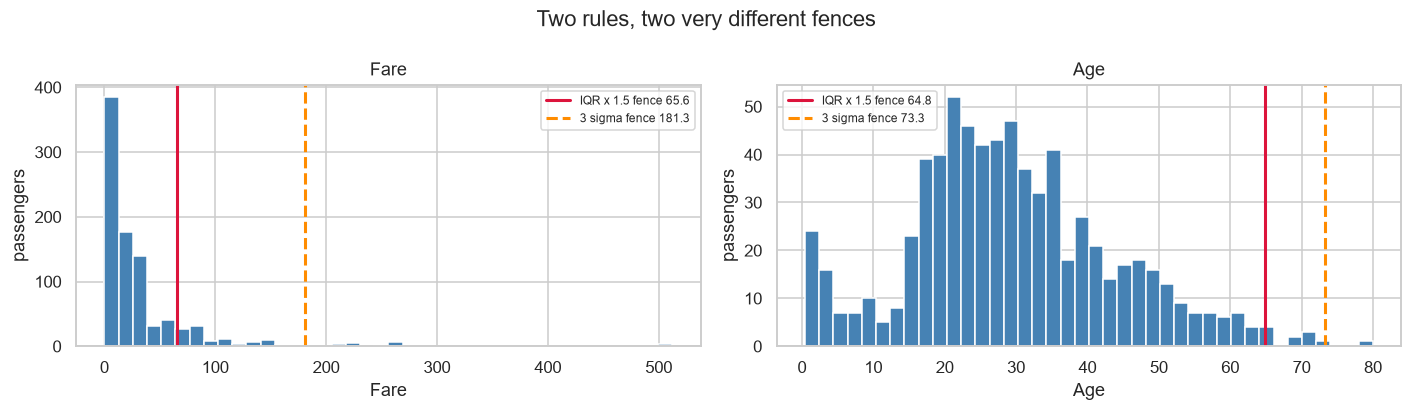

                                   Name  Pclass    Ticket     Fare
258                    Ward, Miss. Anna       1  PC 17755 512.3292
679  Cardeza, Mr. Thomas Drake Martinez       1  PC 17755 512.3292
737              Lesurer, Mr. Gustave J       1  PC 17755 512.3292
27       Fortune, Mr. Charles Alexander       1     19950 263.0000
88           Fortune, Miss. Mabel Helen       1     19950 263.0000

how many passengers share each of the most expensive tickets:
Ticket
PC 17755    3
Name: Name, dtype: int64

fares of exactly zero: 15


In [15]:
def _sigma_rule(series, k=3.0):
    """The Practice 1 rule: more than k standard deviations from the mean."""
    mu, sd = series.mean(), series.std()
    mask = ((series - mu).abs() > k * sd).fillna(False).astype(bool)
    return {"lower": float(mu - k * sd), "upper": float(mu + k * sd), "mask": mask}

def _rule_table(series):
    rows = []
    for _m in (1.0, 1.5, 3.0, 5.0):
        _r = iqr_outliers(series, _m)
        rows.append({"rule": f"IQR x {_m}", "lower": _r["lower"],
                     "upper": _r["upper"], "flagged": int(_r["mask"].sum())})
    _s = _sigma_rule(series)
    rows.append({"rule": "3 sigma", "lower": _s["lower"], "upper": _s["upper"],
                 "flagged": int(_s["mask"].sum())})
    out = pd.DataFrame(rows).set_index("rule")
    out["percent"] = (100 * out["flagged"] / int(series.notna().sum())).round(2)
    return out

print("Fare")
print(_rule_table(titanic["Fare"]).round(3))
print("\nAge")
print(_rule_table(titanic["Age"]).round(3))

print("\nshape of the two columns")
print(pd.DataFrame({
    "mean": [titanic["Fare"].mean(), titanic["Age"].mean()],
    "median": [titanic["Fare"].median(), titanic["Age"].median()],
    "std": [titanic["Fare"].std(), titanic["Age"].std()],
    "skew": [titanic["Fare"].skew(), titanic["Age"].skew()],
    "kurtosis": [titanic["Fare"].kurtosis(), titanic["Age"].kurtosis()],
    "max": [titanic["Fare"].max(), titanic["Age"].max()],
}, index=["Fare", "Age"]).round(3))

# What happens to the 3 sigma fence once the extreme fares are removed?
_kept = titanic.loc[~iqr_outliers(titanic["Fare"])["mask"], "Fare"]
print(f"\nFare, all 891 rows          : std {titanic['Fare'].std():7.3f}"
      f"  -> 3 sigma upper fence {titanic['Fare'].mean() + 3 * titanic['Fare'].std():7.2f}")
print(f"Fare, IQR-flagged removed   : std {_kept.std():7.3f}"
      f"  -> 3 sigma upper fence {_kept.mean() + 3 * _kept.std():7.2f}")

_fig, _axs = plt.subplots(1, 2, figsize=(13.0, 3.8))
for _ax, _col in zip(_axs, ("Fare", "Age")):
    _ax.hist(titanic[_col].dropna(), bins=40, color="steelblue", edgecolor="white")
    _r = iqr_outliers(titanic[_col])
    _s = _sigma_rule(titanic[_col])
    _ax.axvline(_r["upper"], color="crimson", lw=2,
                label=f"IQR x 1.5 fence {_r['upper']:.1f}")
    _ax.axvline(_s["upper"], color="darkorange", lw=2, ls="--",
                label=f"3 sigma fence {_s['upper']:.1f}")
    _ax.set_title(_col)
    _ax.set_xlabel(_col)
    _ax.set_ylabel("passengers")
    _ax.legend(fontsize=8)
_fig.suptitle("Two rules, two very different fences")
_fig.tight_layout()
plt.show()

# What are the largest fares, actually?
print(titanic.nlargest(5, "Fare")[["Name", "Pclass", "Ticket", "Fare"]])
print("\nhow many passengers share each of the most expensive tickets:")
print(titanic[titanic["Fare"] > 300].groupby("Ticket")["Name"].count())
print(f"\nfares of exactly zero: {int((titanic['Fare'] == 0).sum())}")

**Your answer:**

**(a) Five numbers on `Fare`.**

| rule | fences | flagged | share |
|---|---|---|---|
| IQR x 1.0 | [-15.18, 54.09] | 141 | 15.82 % |
| IQR x 1.5 | [-26.72, 65.63] | 116 | 13.02 % |
| IQR x 3.0 | [-61.36, 100.27] | 53 | 5.95 % |
| IQR x 5.0 | [-107.54, 146.45] | 31 | 3.48 % |
| 3 sigma | [-116.88, 181.28] | **20** | 2.24 % |

**(b) Why they disagree, and which one is inflated.** `Fare` has skew
**4.787** and kurtosis **33.398**; its mean is **32.204** against a median
of **14.454** and a maximum of 512.33. The 3 sigma rule is built from the
mean and the standard deviation, and **both are computed from the same data
that contains the extreme fares**. The IQR rule is built from Q1 and Q3,
which are order statistics: moving the largest fare from 512 to 5 000 would
not move Q3 by a penny.

That is the mechanism, and it is measurable. With every row included the
standard deviation is **49.693** and the 3 sigma fence lands at **181.28**.
Remove the 116 points the IQR rule flags and the standard deviation falls
to **13.578**, putting the same fence at **58.56** — a third of its former
value. The 3 sigma rule is therefore the one inflated by the very points it
is meant to detect: each extreme fare enlarges the sigma that is supposed
to catch it, the fence retreats, and the rule ends up flagging 20 points
where the quantile rule flags 116. This is masking, and it gets worse the
heavier the tail.

**(c) The same two rules on `Age`.** They very nearly agree: IQR x 1.5
flags **11** passengers (1.54 %), 3 sigma flags **2** (0.28 %), and at
IQR x 3.0 the count is **0**. What is different is the shape. `Age` has
skew **0.389** and kurtosis **0.178** — close to symmetric, with tails no
heavier than a normal's — and it is bounded by biology at 0.42 and 80. The
mean (29.70) and the median (28.00) are 1.7 years apart, against 17.75 for
`Fare`. When the distribution is roughly symmetric and light-tailed, the
mean/sigma pair and the quantile pair describe the same middle, so the two
rules draw fences in almost the same place. The disagreement on `Fare` was
never about the multiplier; it was about the distribution.

**(d) Would I remove the flagged fares? No.** Not because 13 % is too
many, but because of what the column means. The three highest fares are
512.3292 each and they are **the same ticket**: `PC 17755`, held by Ward,
Cardeza and Lesurer. The recorded `Fare` is the price of the whole booking
repeated on every passenger of the party, not a price per person — so the
number is not an error, it is a per-party total wearing a per-passenger
label. The correct response is to repair the meaning (divide the fare by
the number of passengers sharing that ticket), not to delete the rows. The
same argument runs the other way at the bottom of the column: the **15
fares of exactly 0** are a recording convention for crew and guests, not
free tickets, and they are inside every fence so no rule would catch them.
Deleting the flagged rows would also delete most of first class, which is
the group the survival question is actually about.

## 7. Task 6 — Pearson against Spearman

Applied. Two coefficients, two different questions about the same pair of
columns.

*see Practice 2 §11.2*

In [16]:
def correlation_pair(frame, column_a, column_b):
    """Compare the two correlation coefficients for one pair of columns.

    Return a dict with exactly these three keys:
        'pearson'     the Pearson coefficient, measuring LINEAR association
        'spearman'    the Spearman coefficient, measuring MONOTONIC association
        'difference'  pearson - spearman

    Use pandas' Series.corr(method=...). Return Python floats.
    """
    a, b = frame[column_a], frame[column_b]
    pearson = float(a.corr(b, method="pearson"))
    spearman = float(a.corr(b, method="spearman"))
    return {
        "pearson": pearson,
        "spearman": spearman,
        "difference": pearson - spearman,
    }

In [17]:
_pair = correlation_pair(wine, "flavanoids", "total_phenols")

assert set(_pair) == {"pearson", "spearman", "difference"}
assert np.isclose(_pair["pearson"], 0.8646, atol=1e-3), f"pearson wrong: {_pair['pearson']}"
assert np.isclose(_pair["spearman"], 0.8794, atol=1e-3), f"spearman wrong: {_pair['spearman']}"
assert np.isclose(_pair["difference"], _pair["pearson"] - _pair["spearman"])

# A perfectly linear pair: both coefficients are exactly 1.
_linear = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0, 5.0], "b": [3.0, 5.0, 7.0, 9.0, 11.0]})
_lin = correlation_pair(_linear, "a", "b")
assert np.isclose(_lin["pearson"], 1.0) and np.isclose(_lin["spearman"], 1.0)

# Monotonic but strongly curved: Spearman sees it fully, Pearson does not.
_curve_rng = np.random.default_rng(SEED)
_x = np.linspace(0.1, 5.0, 300)
_curved = pd.DataFrame({"x": _x, "y": np.exp(_x) + _curve_rng.normal(0, 3, 300)})
_c = correlation_pair(_curved, "x", "y")
assert _c["spearman"] > 0.95, f"a monotonic pair should have Spearman near 1, got {_c['spearman']:.4f}"
assert _c["pearson"] < _c["spearman"] - 0.05, \
    "on a curved monotonic pair Pearson must fall clearly below Spearman"

print(f"wine flavanoids vs total_phenols: pearson {_pair['pearson']:+.4f}  "
      f"spearman {_pair['spearman']:+.4f}")
print(f"curved monotonic pair          : pearson {_c['pearson']:+.4f}  "
      f"spearman {_c['spearman']:+.4f}")
print("Task 6 passed.")

wine flavanoids vs total_phenols: pearson +0.8646  spearman +0.8794
curved monotonic pair          : pearson +0.8605  spearman +0.9653
Task 6 passed.


### Question 3 — two coefficients, and the bandwidth that shapes what you see

**(a)** Scatter-plot the curved pair `_curved` from the cell above. Both
coefficients are high, and they disagree by about 0.10. Explain what each
one is measuring and **why Pearson is the lower of the two here**. Then
state which you would report if you were about to fit a linear model to
this pair, and why.

**(b)** Run `correlation_pair` on `color_intensity` against `hue` in the
wine data. Here the two differ in a different way. Plot the pair and
explain what feature of the data produces the gap.

**(c)** Now a different decision that changes what you see. Take Titanic's
`Age` and draw `sns.kdeplot` at `bw_adjust` = 0.2, 1.0 and 3.0, then draw
a histogram of the same column at 20 and at 200 bins. **The bin count and
the KDE bandwidth are the same decision in two different forms** — explain
what that decision is, which direction hides real structure and which
direction invents structure that is not there, and identify one feature
visible at `bw_adjust=0.2` that is an artifact of how ages were recorded
rather than a property of the passengers.

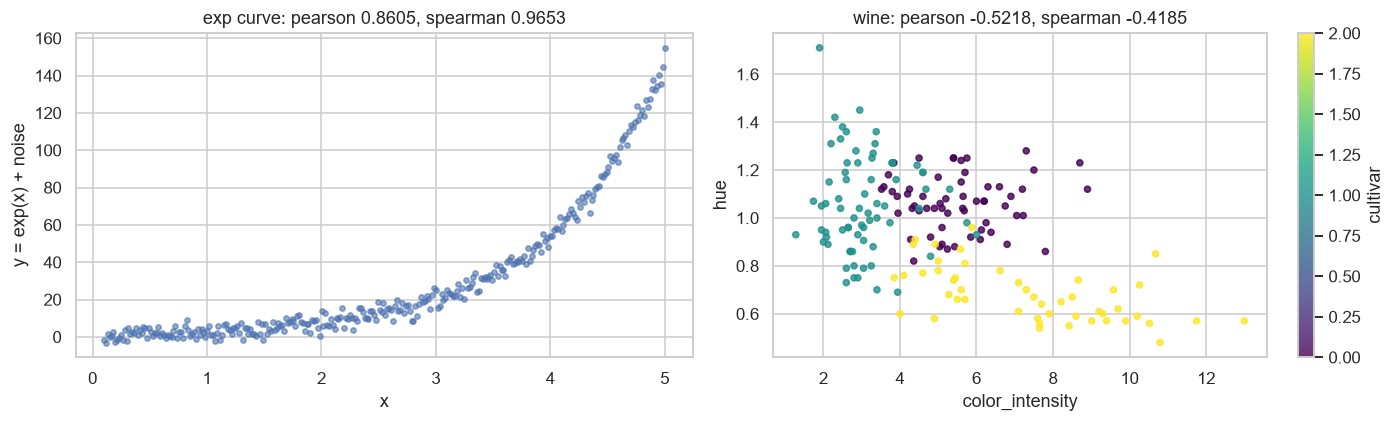

color_intensity vs hue, all 178 wines: {'pearson': -0.5218, 'spearman': -0.4185, 'difference': -0.1033}

the same pair computed inside each cultivar:
  cultivar 0: n  59  pearson +0.0282  spearman -0.0182
  cultivar 1: n  71  pearson -0.0261  spearman +0.0284
  cultivar 2: n  48  pearson -0.5686  spearman -0.5820

color_intensity by cultivar (the tail lives in one of them):
         count   mean    std    min    25%    50%    75%     max
target                                                          
0      59.0000 5.5280 1.2390 3.5200 4.5500 5.4000 6.2250  8.9000
1      71.0000 3.0870 0.9250 1.2800 2.5350 2.9000 3.4000  6.0000
2      48.0000 7.3960 2.3110 3.8500 5.4380 7.5500 9.2250 13.0000


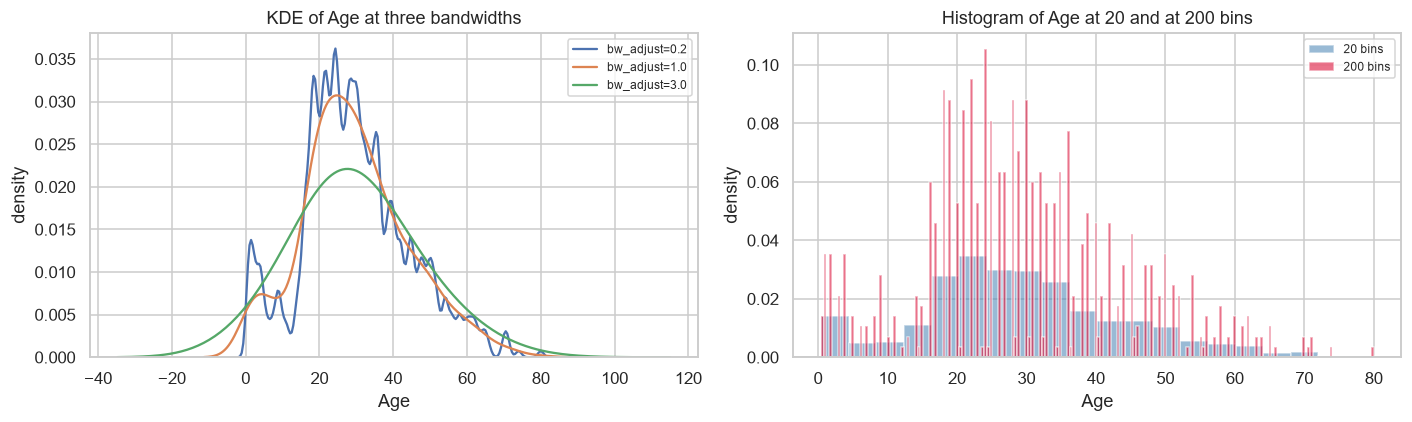

recorded ages that are whole numbers: 96.50%
recorded ages that are fractions    : 25  -> [np.float64(0.42), np.float64(0.67), np.float64(0.75), np.float64(0.83), np.float64(0.92), np.float64(14.5)] ...

the ten most frequent recorded ages:
Age
24.0000    30
22.0000    27
18.0000    26
28.0000    25
19.0000    25
30.0000    25
21.0000    24
25.0000    23
36.0000    22
29.0000    20
Name: count, dtype: int64

a round age against its two neighbours:
    19:  25   |  20:  15|     21:  24
    24:  30   |  25:  23|     26:  18
    29:  20   |  30:  25|     31:  17
    34:  15   |  35:  18|     36:  22
    39:  14   |  40:  13|     41:   6
    44:   9   |  45:  12|     46:   3
    49:   6   |  50:  10|     51:   7


In [18]:
# (a) the curved monotonic pair, and (b) wine colour against hue
_ch = correlation_pair(wine, "color_intensity", "hue")

_fig, _axs = plt.subplots(1, 2, figsize=(13.0, 4.0))
_axs[0].scatter(_curved["x"], _curved["y"], s=12, alpha=0.6)
_axs[0].set_title(f"exp curve: pearson {_c['pearson']:.4f}, spearman {_c['spearman']:.4f}")
_axs[0].set_xlabel("x")
_axs[0].set_ylabel("y = exp(x) + noise")

_sc = _axs[1].scatter(wine["color_intensity"], wine["hue"], s=16, alpha=0.8,
                      c=wine["target"], cmap="viridis")
_axs[1].set_title(f"wine: pearson {_ch['pearson']:.4f}, spearman {_ch['spearman']:.4f}")
_axs[1].set_xlabel("color_intensity")
_axs[1].set_ylabel("hue")
_fig.colorbar(_sc, ax=_axs[1], label="cultivar")
_fig.tight_layout()
plt.show()

print("color_intensity vs hue, all 178 wines:",
      {_k: round(_v, 4) for _k, _v in _ch.items()})
print("\nthe same pair computed inside each cultivar:")
for _t, _grp in wine.groupby("target"):
    _p = correlation_pair(_grp, "color_intensity", "hue")
    print(f"  cultivar {_t}: n {len(_grp):3d}  pearson {_p['pearson']:+.4f}"
          f"  spearman {_p['spearman']:+.4f}")

print("\ncolor_intensity by cultivar (the tail lives in one of them):")
print(wine.groupby("target")["color_intensity"].describe().round(3))

# (c) bin count and bandwidth are the same decision
_fig, _axs = plt.subplots(1, 2, figsize=(13.0, 4.0))
for _bw in (0.2, 1.0, 3.0):
    sns.kdeplot(titanic["Age"].dropna(), bw_adjust=_bw, ax=_axs[0],
                label=f"bw_adjust={_bw}")
_axs[0].set_title("KDE of Age at three bandwidths")
_axs[0].set_xlabel("Age")
_axs[0].set_ylabel("density")
_axs[0].legend(fontsize=8)

_axs[1].hist(titanic["Age"].dropna(), bins=20, alpha=0.55, density=True,
             color="steelblue", edgecolor="white", label="20 bins")
_axs[1].hist(titanic["Age"].dropna(), bins=200, alpha=0.60, density=True,
             color="crimson", label="200 bins")
_axs[1].set_title("Histogram of Age at 20 and at 200 bins")
_axs[1].set_xlabel("Age")
_axs[1].set_ylabel("density")
_axs[1].legend(fontsize=8)
_fig.tight_layout()
plt.show()

# How were the ages actually recorded?
_recorded = titanic["Age"].dropna()
print(f"recorded ages that are whole numbers: {(_recorded % 1 == 0).mean():.2%}")
print(f"recorded ages that are fractions    : {int((_recorded % 1 != 0).sum())}"
      f"  -> {sorted(_recorded[_recorded % 1 != 0].unique())[:6]} ...")
print("\nthe ten most frequent recorded ages:")
print(_recorded.value_counts().head(10))
print("\na round age against its two neighbours:")
for _a in (20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0):
    print(f"  {_a - 1:4.0f}: {int((_recorded == _a - 1).sum()):3d}"
          f"   |{_a:4.0f}: {int((_recorded == _a).sum()):3d}|"
          f"   {_a + 1:4.0f}: {int((_recorded == _a + 1).sum()):3d}")

**Answer:**

**(a) The curved pair.** Pearson **0.8605**, Spearman **0.9653**. Pearson
measures how close the cloud sits to a *straight line*: it is the
covariance of the two variables divided by their standard deviations, so it
is maximal only for an exactly affine relationship. Spearman is the same
coefficient computed on the *ranks*, so it measures whether y rises
whenever x rises, irrespective of by how much. The pair is
`y = exp(x) + noise`: strictly increasing, so the ranks line up almost
perfectly and Spearman is near 1, while the curve bends away from any
straight line, and that bend is exactly the variance a linear fit cannot
absorb. Pearson is the lower of the two because it is the only one of the
two that is penalised by curvature.

If I were about to fit a **linear** model to this pair I would report
**Pearson, 0.8605**, because it is the coefficient that describes what that
model can actually capture — Spearman's 0.9653 would advertise a fit the
model cannot deliver. The more useful move is to report both and read the
gap as a diagnostic: a large Spearman with a smaller Pearson says "strong
relationship, wrong functional form", and the fix is to fit `log(y)` rather
than to accept the worse coefficient.

**(b) `color_intensity` against `hue`.** Pearson **-0.5218**, Spearman
**-0.4185**, difference **-0.1033**. Here Pearson is the *stronger* of the
two, which is the opposite of (a), and the scatter says why. The wines fall
into three cultivars sitting at three different colour levels (mean
`color_intensity` 5.53, 3.09 and 7.40), and cultivar 2 carries a long right
tail out to 13.0 against a median of 7.55. Those few far-right, low-hue
points are high-leverage for a straight line and they pull Pearson down
hard; ranks compress them to "the largest few", so Spearman barely notices.

The gap is therefore produced by a handful of extreme `color_intensity`
values acting on a coefficient that is sensitive to magnitude. And the
correlation itself is largely a between-group artefact: computed inside
each cultivar it is **+0.0282**, **-0.0261** and **-0.5686**. Two of the
three groups show no relationship at all. The pooled -0.52 describes the
arrangement of the cultivars, not a law relating colour to hue in a wine —
the same pooling problem as Question 8.

**(c) Bin count and bandwidth.** Both are the same decision: **how much of
the data to pool into one local estimate** — how wide a neighbourhood
around a point contributes to the height drawn at that point. A histogram
spends that decision on bin width, a KDE on bandwidth, and in both the
choice trades bias against variance. Smoothing too much (`bw_adjust=3.0`,
20 bins) is the biased direction: it **hides real structure**, flattening
the child bump around age 4 and the young-adult mode into one broad hill.
Smoothing too little (`bw_adjust=0.2`, 200 bins) is the noisy direction: it
**invents structure**, drawing a separate peak wherever two or three
passengers happen to share a value.

The artifact visible at `bw_adjust=0.2` is the **comb of narrow spikes at
whole-number ages**. **96.50 %** of the recorded ages are integers, and the
only 25 fractional values are infants under one (0.42, 0.67, 0.75, 0.83,
0.92) plus a handful of half-years. `Age` is therefore not a continuous
measurement at all — it is a heavily rounded, self-reported integer, and
the heaping shows through in the counts (age 24 appears 30 times, 22
appears 27, 18 appears 26, while 20 appears only 15 and 31 only 17). Those
spikes are a property of how the ages were **recorded**, not of how old the
passengers were: nobody aboard was more likely to be exactly 24 than 23 and
a half. At `bw_adjust=1.0` the comb disappears and the two real features —
the infant bump and the 20-to-30 mode — are what remains.

## 8. Task 7 — Encoding, and the distances it invents

Applied. Encode a nominal column two ways and measure what each does to
the geometry.

*see Practice 2 §13*

In [19]:
def encoding_distances(series):
    """Compare label encoding against one-hot encoding on a nominal column.

    `series` holds categorical text with no missing values.

    Build both encodings:
      - label:   the categories sorted alphabetically, mapped to 0, 1, 2, ...
      - one-hot: one binary column per category

    Then, for every unordered pair of DISTINCT categories, compute the
    Euclidean distance between their encodings under each scheme.

    Return a DataFrame with one row per pair, indexed by the string
    "A|B" with A and B in alphabetical order, and two columns:
        'label_distance'    |code(A) - code(B)|
        'onehot_distance'   the Euclidean distance between the two one-hot rows

    Rows sorted by index.
    """
    from itertools import combinations

    categories = sorted(series.unique())
    code = {name: i for i, name in enumerate(categories)}

    # One representative row per category under one-hot, so the distances
    # below are measured off a real encoding rather than asserted.
    onehot = pd.get_dummies(pd.Series(categories, index=categories)).astype(float)

    rows = {}
    for a, b in combinations(categories, 2):
        rows[f"{a}|{b}"] = {
            "label_distance": float(abs(code[a] - code[b])),
            "onehot_distance": float(
                np.linalg.norm(onehot.loc[a].to_numpy() - onehot.loc[b].to_numpy())
            ),
        }

    return pd.DataFrame(rows).T[["label_distance", "onehot_distance"]].sort_index()

In [20]:
_embarked = titanic["Embarked"].fillna("S")
_distances = encoding_distances(_embarked)

assert list(_distances.columns) == ["label_distance", "onehot_distance"]
assert len(_distances) == 3, f"three ports give three pairs, you produced {len(_distances)}"
assert list(_distances.index) == ["C|Q", "C|S", "Q|S"], f"index wrong: {list(_distances.index)}"

# Label encoding invents an ordering: C and S end up twice as far apart.
assert np.isclose(_distances.loc["C|Q", "label_distance"], 1.0)
assert np.isclose(_distances.loc["C|S", "label_distance"], 2.0)
assert np.isclose(_distances.loc["Q|S", "label_distance"], 1.0)

# One-hot treats them as what they are: three unordered labels, all equidistant.
assert np.allclose(_distances["onehot_distance"], np.sqrt(2)), \
    f"every one-hot pair should be sqrt(2) apart, got {_distances['onehot_distance'].tolist()}"
assert _distances["onehot_distance"].nunique() == 1, \
    "one-hot must not distinguish any pair from any other"

print(_distances.round(4))
print("\nTask 7 passed.")

     label_distance  onehot_distance
C|Q          1.0000           1.4142
C|S          2.0000           1.4142
Q|S          1.0000           1.4142

Task 7 passed.


### Question 4 — label against one-hot

**(a)** Under label encoding, C and S are 2 apart while C and Q are 1
apart. Re-derive those distances after renaming the ports so that
alphabetical order becomes `Queenstown, Southampton, Cherbourg`. What
happens to the geometry? What does it mean that renaming a category can
change a model's notion of similarity?

**(b)** `Pclass` also becomes integers 1, 2, 3, and Practice 2 §13.3 says
that is **correct**. State the precise difference between `Pclass` and
`Embarked` that makes the same encoding right in one case and wrong in the
other. Your answer must not mention the data type.

**(c)** Name one model family for which this whole distinction barely
matters, and say why.

In [21]:
# (a) the same three ports, renamed. Nothing about the passengers changes,
# only the strings do -- and with them the alphabetical order that label
# encoding reads as a scale. "Zherbourg" is deliberately misspelt so that
# Cherbourg sorts last: Queenstown, Southampton, Zherbourg.
_relabel = {"Q": "Queenstown", "S": "Southampton", "C": "Zherbourg"}
_renamed = _embarked.map(_relabel)

print("original labels C, Q, S -> codes 0, 1, 2")
print(_distances.round(4))
print("\nrenamed, so the codes become Queenstown 0, Southampton 1, Zherbourg 2")
print(encoding_distances(_renamed).round(4))

print("\nthe passengers did not move, only the strings did:")
for _old, _new in sorted(_relabel.items()):
    print(f"  {_old} -> {_new:12s} {int((_embarked == _old).sum()):3d} passengers"
          f"  (renamed column: {int((_renamed == _new).sum()):3d})")

# (b) Pclass really is ordered: the quantities it indexes move with it.
print("\nPclass, against quantities that would reveal an order:")
print(titanic.groupby("Pclass").agg(
    n=("Survived", "size"),
    median_fare=("Fare", "median"),
    survival_rate=("Survived", "mean"),
).round(4))

print("\nthe same table for Embarked, where no such order exists:")
print(titanic.groupby("Embarked").agg(
    n=("Survived", "size"),
    median_fare=("Fare", "median"),
    survival_rate=("Survived", "mean"),
).round(4))

# Is the midpoint meaningful? For Pclass, class 2 sits between 1 and 3.
# For Embarked under label encoding, Q would have to sit between C and S.
print("\nis the middle category between the other two?")
_pc = titanic.groupby("Pclass")["Fare"].median()
print(f"  Pclass  : median fare {_pc[1]:.2f} > {_pc[2]:.2f} > {_pc[3]:.2f}"
      f"  -> monotone, so 1 < 2 < 3 means something")
_em = titanic.groupby("Embarked")["Fare"].median()
print(f"  Embarked: median fare C {_em['C']:.2f}, Q {_em['Q']:.2f}, S {_em['S']:.2f}"
      f"  -> Q is not between C and S in any sense the code implies")

original labels C, Q, S -> codes 0, 1, 2
     label_distance  onehot_distance
C|Q          1.0000           1.4142
C|S          2.0000           1.4142
Q|S          1.0000           1.4142

renamed, so the codes become Queenstown 0, Southampton 1, Zherbourg 2
                        label_distance  onehot_distance
Queenstown|Southampton          1.0000           1.4142
Queenstown|Zherbourg            2.0000           1.4142
Southampton|Zherbourg           1.0000           1.4142

the passengers did not move, only the strings did:
  C -> Zherbourg    168 passengers  (renamed column: 168)
  Q -> Queenstown    77 passengers  (renamed column:  77)
  S -> Southampton  646 passengers  (renamed column: 646)

Pclass, against quantities that would reveal an order:
          n  median_fare  survival_rate
Pclass                                 
1       216      60.2875         0.6296
2       184      14.2500         0.4728
3       491       8.0500         0.2424

the same table for Embarked, wher

**Your answer:**

**(a) Renaming the ports.** With the original labels, alphabetical order is
C, Q, S, so the codes are 0, 1, 2 and the distances are C|Q = 1,
**C|S = 2**, Q|S = 1. Rename the same three ports so that the order becomes
Queenstown, Southampton, Zherbourg and the codes become 0, 1, 2 in that
order, giving Queenstown|Southampton = 1, **Queenstown|Zherbourg = 2**,
Southampton|Zherbourg = 1.

The geometry has been rearranged. Cherbourg and Southampton, which the
first encoding placed twice as far apart as any other pair, are now
adjacent; Cherbourg and Queenstown, which were adjacent, are now the
extreme pair. Not one passenger moved: 168 still embarked at Cherbourg, 77
at Queenstown and 646 at Southampton (the 644 recorded, plus the two
missing values Task 7 fills with `S`), and all of the survival rates are
untouched.

What it means that a rename can do this: under label encoding the notion of
similarity a model receives is a property of **the spelling of the
categories**, not of the categories. Any model that reads the code as a
quantity — a linear or logistic regression, a distance-based method like
k-NN or k-means, anything that standardises — will conclude that Cherbourg
resembles Queenstown more than it resembles Southampton, and will conclude
the opposite if a data engineer corrects a typo. A quantity that changes
when you rename its labels was not measuring anything.

**(b) Why the same encoding is right for `Pclass`.** Because `Pclass`
indexes a real ordering and `Embarked` does not, and the difference is
visible in the quantities each one predicts. Along `Pclass` the world moves
monotonically with the code: median fare **60.29 > 14.25 > 8.05** and
survival rate **0.6296 > 0.4728 > 0.2424**. Second class genuinely lies
*between* first and third on price, on deck position and on outcome, so the
statement the integers make — that 2 is between 1 and 3, and that the two
steps are comparable — is at least approximately a statement about the
world, and one that a model can use.

`Embarked` supports no such statement. There is no quantity under which
Queenstown lies between Cherbourg and Southampton: median fare is 29.70 at
Cherbourg, **7.75 at Queenstown** and 13.00 at Southampton, which puts
Queenstown at the extreme, not in the middle, and survival runs 0.5536 /
0.3896 / 0.3370. An alphabetical code would assert an ordering and a
midpoint that the ports do not have, and the (a) rename shows that the
assertion can be reversed at will. One-hot encoding asserts nothing: every
pair of ports is sqrt(2) apart, which is the honest statement that they are
three labels and nothing more.

**(c) Where the distinction barely matters.** **Tree ensembles** — a
decision tree, a random forest, gradient boosting. A tree only ever uses a
feature to answer "is this value above or below a threshold", and it can
place as many thresholds on one column as it needs; it never multiplies the
code by a coefficient or measures a distance with it, so the *magnitude* of
the gap between codes is invisible to it. Splitting `Embarked <= 0.5` and
then `Embarked <= 1.5` isolates all three ports exactly, whatever the
labels happened to be. The cost is depth, not correctness — and the one
thing the tree still cannot do in a single split is group two
non-adjacent codes together, which is why a real implementation prefers
native categorical support where it exists.

## 9. Task 8 — Scale without leaking

Applied. Split, then fit the scaler on the training half only.

*see Practice 2 §14.3*

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def split_and_scale(X, y, test_size=0.3, random_state=SEED):
    """Split into train and test, then standardise WITHOUT leakage.

    Split first with train_test_split, stratifying on y and using the
    given random_state. Then fit a StandardScaler on the TRAINING features
    only, and use it to transform both halves.

    Return a dict with exactly these five keys:
        'X_train', 'X_test'   the scaled feature arrays
        'y_train', 'y_test'   the labels
        'scaler'              the fitted StandardScaler
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # fit on the training half, transform both. The test rows contribute
    # nothing to the mean or the variance, which is the whole point.
    scaler = StandardScaler().fit(X_train)

    return {
        "X_train": scaler.transform(X_train),
        "X_test": scaler.transform(X_test),
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler,
    }

In [23]:
_features = [c for c in wine.columns if c != "target"]
_split = split_and_scale(wine[_features].values, wine["target"].values)

assert set(_split) == {"X_train", "X_test", "y_train", "y_test", "scaler"}
assert _split["X_train"].shape[0] + _split["X_test"].shape[0] == len(wine)
assert _split["X_train"].shape[1] == 13

# The TRAINING half must be exactly standardised...
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-10), \
    "the training set should have mean 0 after scaling"
assert np.allclose(_split["X_train"].std(axis=0), 1.0, atol=1e-10), \
    "the training set should have unit variance after scaling"

# ...and the TEST half must NOT be, because its statistics were never used.
assert not np.allclose(_split["X_test"].mean(axis=0), 0.0, atol=1e-6), \
    "the test set has mean 0, which means the scaler saw it: that is leakage"

# The scaler must have been fitted on the training rows only.
_leaky = StandardScaler().fit(wine[_features].values)
assert not np.allclose(_split["scaler"].mean_, _leaky.mean_), \
    "your scaler's means match a scaler fitted on the whole dataset"

# stratify= must preserve the class balance
_train_balance = np.bincount(_split["y_train"]) / len(_split["y_train"])
_full_balance = np.bincount(wine["target"].values) / len(wine)
assert np.allclose(_train_balance, _full_balance, atol=0.02), \
    "the class balance was not preserved; did you pass stratify=y?"

print("train", _split["X_train"].shape, " test", _split["X_test"].shape)
print("train mean (first 3 features):", _split["X_train"].mean(axis=0)[:3].round(10))
print("test  mean (first 3 features):", _split["X_test"].mean(axis=0)[:3].round(4), " <- not zero, correctly")
print("\nTask 8 passed.")

train (124, 13)  test (54, 13)
train mean (first 3 features): [ 0. -0. -0.]
test  mean (first 3 features): [-0.0324  0.0259 -0.0291]  <- not zero, correctly

Task 8 passed.


### Question 5 — scaling choices

**(a)** Repeat Task 8 with `MinMaxScaler` instead. Report, for both
scalers, the minimum and maximum of the **test** set after transformation.
Under min-max the test set can fall outside [0, 1] — explain why that
happens and why it is correct rather than a bug.

**(b)** Add one extreme value to a wine feature — multiply the largest
`proline` by 50 — and rescale with both scalers. Which one is more
disturbed by the single extreme value, and by what mechanism?

**(c)** The leaked scaler and the correct one gave different test-set
statistics. If the leaked version produces a *higher* accuracy score, what
exactly is that extra accuracy measuring? Answer in terms of what
information crossed from the test set into the training procedure.

In [24]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

_Xw = wine[_features].values
_yw = wine["target"].values
_Xtr_raw, _Xte_raw, _ytr, _yte = train_test_split(
    _Xw, _yw, test_size=0.3, random_state=SEED, stratify=_yw
)

# (a) both scalers, each fitted on the training half only
_std = StandardScaler().fit(_Xtr_raw)
_mm = MinMaxScaler().fit(_Xtr_raw)

print("range of the transformed data, all 13 features pooled")
print(pd.DataFrame({
    "train_min": [_std.transform(_Xtr_raw).min(), _mm.transform(_Xtr_raw).min()],
    "train_max": [_std.transform(_Xtr_raw).max(), _mm.transform(_Xtr_raw).max()],
    "test_min": [_std.transform(_Xte_raw).min(), _mm.transform(_Xte_raw).min()],
    "test_max": [_std.transform(_Xte_raw).max(), _mm.transform(_Xte_raw).max()],
}, index=["StandardScaler", "MinMaxScaler"]).round(4))

_mm_test = _mm.transform(_Xte_raw)
print(f"\ntest values below 0 under min-max: {int((_mm_test < 0).sum())}")
print(f"test values above 1 under min-max: {int((_mm_test > 1).sum())}")
print("\nper-feature range of the min-max test set:")
print(pd.DataFrame({"min": _mm_test.min(axis=0), "max": _mm_test.max(axis=0)},
                   index=_features).round(4))

# (b) one extreme value, and what each scaler does about it
_proline = _features.index("proline")
_Xw_spike = _Xw.copy()
_spike_row = int(np.argmax(_Xw_spike[:, _proline]))
_original = _Xw_spike[_spike_row, _proline]
_Xw_spike[_spike_row, _proline] = _original * 50
print(f"\nproline of row {_spike_row}: {_original:.1f} -> {_original * 50:.1f}")

_before_std = StandardScaler().fit_transform(_Xw)[:, _proline]
_after_std = StandardScaler().fit_transform(_Xw_spike)[:, _proline]
_before_mm = MinMaxScaler().fit_transform(_Xw)[:, _proline]
_after_mm = MinMaxScaler().fit_transform(_Xw_spike)[:, _proline]

_others = np.ones(len(_Xw), dtype=bool)
_others[_spike_row] = False

def _describe(values):
    return {"min": values.min(), "max": values.max(),
            "std": values.std(), "range": values.max() - values.min()}

print("\nthe other 177 wines, after scaling the spiked column:")
print(pd.DataFrame({
    "StandardScaler before": _describe(_before_std[_others]),
    "StandardScaler after": _describe(_after_std[_others]),
    "MinMaxScaler before": _describe(_before_mm[_others]),
    "MinMaxScaler after": _describe(_after_mm[_others]),
}).T.round(5))

# (c) the leaked scaler against the correct one
_leaky_scaler = StandardScaler().fit(_Xw)          # saw the test rows
_correct_model = LogisticRegression(max_iter=5000).fit(_std.transform(_Xtr_raw), _ytr)
_leaked_model = LogisticRegression(max_iter=5000).fit(
    _leaky_scaler.transform(_Xtr_raw), _ytr)

print(f"\ncorrect scaler, test accuracy: "
      f"{accuracy_score(_yte, _correct_model.predict(_std.transform(_Xte_raw))):.4f}")
print(f"leaked scaler,  test accuracy: "
      f"{accuracy_score(_yte, _leaked_model.predict(_leaky_scaler.transform(_Xte_raw))):.4f}")
print("\nrelative difference between the two scalers' means, per feature:")
print((np.abs(_std.mean_ - _leaky_scaler.mean_) / np.abs(_std.mean_)).round(5))

range of the transformed data, all 13 features pooled
                train_min  train_max  test_min  test_max
StandardScaler    -3.6570     3.9167   -2.5321    4.7572
MinMaxScaler       0.0000     1.0000   -0.0436    1.1358

test values below 0 under min-max: 3
test values above 1 under min-max: 4

per-feature range of the min-max test set:
                                 min    max
alcohol                       0.1526 0.8816
malic_acid                    0.0356 0.9704
ash                           0.1818 0.9947
alcalinity_of_ash             0.0335 1.0838
magnesium                     0.0988 1.1358
total_phenols                -0.0436 1.0109
flavanoids                   -0.0282 0.7093
nonflavanoid_phenols          0.0800 1.0600
proanthocyanins               0.0726 0.9054
color_intensity               0.0614 0.8933
hue                           0.0488 0.7317
od280/od315_of_diluted_wines  0.0220 0.8938
proline                      -0.0086 0.9043

proline of row 18: 1680.0 -> 84000.0

t

**Your answer:**

**(a) The two scalers on the test set.**

| scaler | test min | test max |
|---|---|---|
| StandardScaler | -2.5321 | 4.7572 |
| MinMaxScaler | **-0.0436** | **1.1358** |

Three test values fall below 0 and four above 1 under min-max — magnesium
reaches 1.1358, total_phenols dips to -0.0436, alcalinity_of_ash reaches
1.0838. This happens because the scaler learned its minimum and maximum
from the **124 training wines only**, and the transform is
`(x - train_min) / (train_max - train_min)`. A test wine richer in
magnesium than any training wine must therefore land above 1; there is no
mechanism that could clip it and still be a fixed, fitted function.

It is correct rather than a bug because the guarantee "everything lies in
[0, 1]" was only ever a guarantee about the data the scaler was fitted on.
If the test set also came out inside [0, 1] exactly, that would mean its
extremes had been used to define the range — which is precisely the leakage
Task 8 is about. An out-of-range test value is the visible proof that the
split was respected, and the same thing will happen in production on the
first customer who is more extreme than anyone in training, which is worth
knowing before it happens.

**(b) One extreme value.** I multiplied the largest proline, row 18, from
**1 680 to 84 000**, then refitted both scalers and looked at what happened
to the **other 177** wines in that column:

| | range before | range after | shrink |
|---|---|---|---|
| StandardScaler | 4.0411 | 0.2037 | ~20x |
| MinMaxScaler | 0.9051 | **0.0152** | **~60x** |

**MinMaxScaler is the more disturbed**, and the mechanism is that its
denominator is `max - min`, a pair of order statistics that a single point
can set entirely. One value fifty times too large multiplies the
denominator by roughly fifty, so all 177 real wines are compressed into the
bottom 1.5 % of the range and become, to any downstream model,
indistinguishable. StandardScaler is damaged too — its denominator is the
standard deviation, and a 50x value dominates a sum of squares — but the
standard deviation is an average over all 178 rows, so the spike is diluted
by the rest of the sample rather than defining the scale outright. That is
the general rule: min-max depends on two individual points, standardisation
on every point, so min-max is the one to avoid when the column has a tail,
and neither is robust (the robust choice here is `RobustScaler`, built from
the median and the IQR, for the reason Question 2 gave).

**(c) What the extra accuracy would be measuring.** In this particular run
the leak produced **no** extra accuracy: correct 0.9815, leaked 0.9815. The
two scalers' per-feature means differ by at most 1.08 %, because 54 test
rows out of 178 barely move a mean, so there was nothing much to steal. The
honest report is that the leak was real but too small to measure here; a
score that does not move is not evidence that leakage is harmless.

Had the leaked version scored higher, the extra would be measuring **how
much it helped to know the test set's own centre and spread**. The
information that crossed the boundary is the test rows' mean and variance:
the leaked model's test features were standardised using statistics that
those very rows helped compute, so each test wine was positioned relative
to a distribution it belongs to. The reported number then estimates
performance on data whose summary statistics were known in advance, and
that is not the situation the model will be in. At deployment the rows
arrive one at a time and there is no test-set mean to normalise against;
whatever accuracy depended on having one does not exist outside the
experiment. The gap between the leaked and the honest score is a
measurement of the experiment's own contamination, not of the model.

## 10. Task 9 — How many principal components

Applied.

*see Practice 2 §15.2 and §15.3*

In [25]:
from sklearn.decomposition import PCA

def components_for_variance(X, thresholds=(0.5, 0.8, 0.95, 0.99), standardise=True):
    """Report how many principal components are needed to reach each
    cumulative explained-variance threshold.

    If `standardise` is True, fit a StandardScaler on X and transform it
    before running PCA. Otherwise use X as given.

    Fit PCA with all components and random_state=SEED.

    Return a dict with two keys:
        'cumulative'  the cumulative explained variance ratio, a 1-D array
        'needed'      a dict mapping each threshold to the SMALLEST number
                      of components whose cumulative variance is >= it,
                      as an int (1 means the first component alone suffices)
    """
    data = StandardScaler().fit_transform(X) if standardise else np.asarray(X)

    pca = PCA(random_state=SEED).fit(data)
    cumulative = np.cumsum(pca.explained_variance_ratio_)

    # argmax on a boolean array returns the first True; +1 turns that
    # index into a count of components.
    needed = {t: int(np.argmax(cumulative >= t)) + 1 for t in thresholds}

    return {"cumulative": cumulative, "needed": needed}

In [26]:
_X_wine = wine[_features].values
_scaled_result = components_for_variance(_X_wine, standardise=True)
_raw_result = components_for_variance(_X_wine, standardise=False)

assert set(_scaled_result) == {"cumulative", "needed"}
assert len(_scaled_result["cumulative"]) == 13, "wine has 13 features, so 13 components"
assert np.isclose(_scaled_result["cumulative"][-1], 1.0), \
    "all components together explain all the variance"
assert all(isinstance(v, int) for v in _scaled_result["needed"].values())

# Monotonic: a higher threshold never needs fewer components.
_counts = [_scaled_result["needed"][t] for t in (0.5, 0.8, 0.95, 0.99)]
assert _counts == sorted(_counts), f"counts must be non-decreasing: {_counts}"

# Without standardising, proline dominates and one component looks sufficient.
assert _raw_result["needed"][0.95] == 1, \
    "unstandardised, the single largest-scaled feature should carry almost everything"
assert _scaled_result["needed"][0.95] > _raw_result["needed"][0.95], \
    "standardising should require more components to reach 95%"

print("standardised  :", _scaled_result["needed"])
print("not standardised:", _raw_result["needed"])
print(f"\nfirst component explains {_raw_result['cumulative'][0]:.2%} unstandardised, "
      f"{_scaled_result['cumulative'][0]:.2%} standardised")
print("\nTask 9 passed.")

standardised  : {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}
not standardised: {0.5: 1, 0.8: 1, 0.95: 1, 0.99: 1}

first component explains 99.81% unstandardised, 36.20% standardised

Task 9 passed.


### Question 6 — components, and the cost of keeping fewer

**(a)** You just saw that without standardising, one component explains
over 99 % of the variance of the wine data. Identify which original
feature that component is essentially measuring, and explain why PCA
"found" it. What does this tell you about running PCA on columns in
different units?

**(b)** Plot the cumulative curve for the standardised wine data. Choosing
95 % gives you one number of components, 80 % gives another. Neither
threshold is derived from anything. Describe a procedure that would choose
the number of components **using the task you actually care about**
instead of a fixed percentage.

**(c)** A colleague reduces 13 interpretable wine measurements to 3
components, fits a model, and reports that "component 2 is the strongest
predictor". What can and cannot be said to a winemaker on the basis of
that sentence?

variance of each raw feature, in its own units:
proline                        99,166.7170
magnesium                         203.9890
alcalinity_of_ash                  11.1530
color_intensity                     5.3740
malic_acid                          1.2480
flavanoids                          0.9980
alcohol                             0.6590
od280/od315_of_diluted_wines        0.5040
total_phenols                       0.3920
proanthocyanins                     0.3280
ash                                 0.0750
hue                                 0.0520
nonflavanoid_phenols                0.0150
dtype: float64

|loading| of the first component, UNSTANDARDISED:
proline             0.9998
magnesium           0.0179
alcalinity_of_ash   0.0047
color_intensity     0.0023
alcohol             0.0017
dtype: float64

correlation of that component with raw proline: +1.000000

|loading| of the first component, STANDARDISED:
flavanoids                     0.4229
total_phenols                  

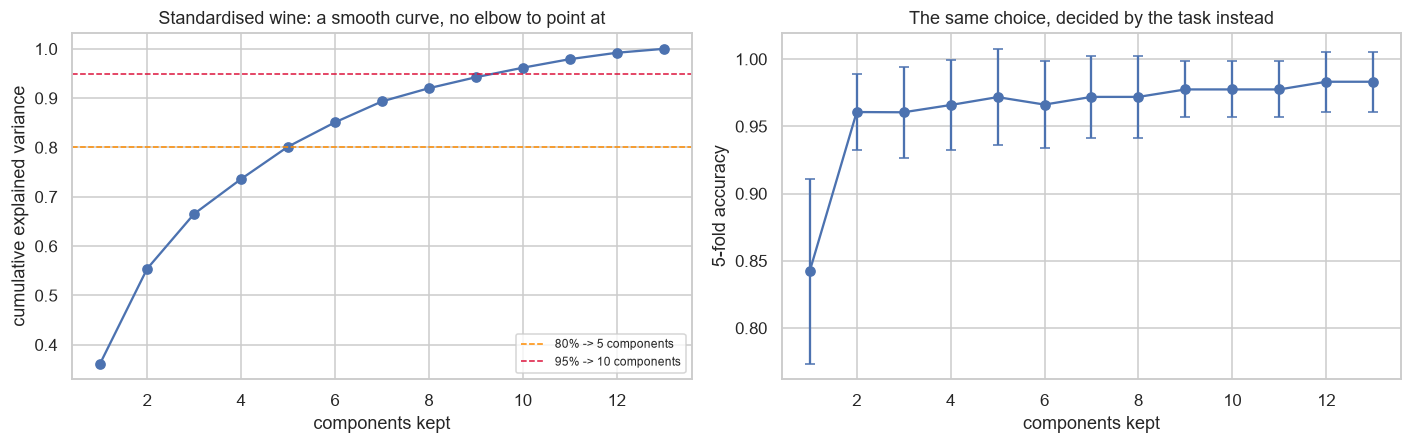


5-fold accuracy against the number of components:
    accuracy     sd  cumulative_variance
k                                       
1     0.8424 0.0688               0.3620
2     0.9606 0.0285               0.5541
3     0.9605 0.0337               0.6653
4     0.9659 0.0333               0.7360
5     0.9717 0.0359               0.8016
6     0.9662 0.0326               0.8510
7     0.9719 0.0304               0.8934
8     0.9719 0.0304               0.9202
9     0.9775 0.0209               0.9424
10    0.9775 0.0209               0.9617
11    0.9775 0.0209               0.9791
12    0.9832 0.0223               0.9920
13    0.9832 0.0223               1.0000

best accuracy at k = 12: 0.9832 (99.20% of the variance)
smallest k within one standard error of the best: 4 (73.60% of the variance)
the 95% threshold would have asked for 10

PC2, standardised: the five original features it weighs most
color_intensity   0.5300
alcohol           0.4837
proline           0.3649
ash               0.

In [27]:
# (a) what is the first unstandardised component actually measuring?
_raw_pca = PCA(random_state=SEED).fit(_X_wine)

print("variance of each raw feature, in its own units:")
print(wine[_features].var().sort_values(ascending=False).round(3))
print("\n|loading| of the first component, UNSTANDARDISED:")
print(pd.Series(np.abs(_raw_pca.components_[0]), index=_features)
      .sort_values(ascending=False).head(5).round(6))
print(f"\ncorrelation of that component with raw proline: "
      f"{np.corrcoef(_raw_pca.transform(_X_wine)[:, 0], wine['proline'])[0, 1]:+.6f}")

_std_pca = PCA(random_state=SEED).fit(StandardScaler().fit_transform(_X_wine))
print("\n|loading| of the first component, STANDARDISED:")
print(pd.Series(np.abs(_std_pca.components_[0]), index=_features)
      .sort_values(ascending=False).head(5).round(4))

# (b) the cumulative curve, and a task-driven alternative to a fixed threshold
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

_cum = _scaled_result["cumulative"]
_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
_rows = []
for _k in range(1, 14):
    _pipe = make_pipeline(StandardScaler(),
                          PCA(n_components=_k, random_state=SEED),
                          LogisticRegression(max_iter=5000))
    _s = cross_val_score(_pipe, _X_wine, wine["target"].values, cv=_cv,
                         scoring="accuracy")
    _rows.append({"k": _k, "accuracy": _s.mean(), "sd": _s.std(),
                  "cumulative_variance": _cum[_k - 1]})
_score_table = pd.DataFrame(_rows).set_index("k")

_fig, _axs = plt.subplots(1, 2, figsize=(13.0, 4.2))
_axs[0].plot(range(1, len(_cum) + 1), _cum, marker="o")
for _t, _color in zip((0.8, 0.95), ("darkorange", "crimson")):
    _axs[0].axhline(_t, ls="--", lw=1, color=_color,
                    label=f"{_t:.0%} -> {_scaled_result['needed'][_t]} components")
_axs[0].set_xlabel("components kept")
_axs[0].set_ylabel("cumulative explained variance")
_axs[0].set_title("Standardised wine: a smooth curve, no elbow to point at")
_axs[0].legend(fontsize=8)

_axs[1].errorbar(_score_table.index, _score_table["accuracy"],
                 yerr=_score_table["sd"], marker="o", capsize=3)
_axs[1].set_xlabel("components kept")
_axs[1].set_ylabel("5-fold accuracy")
_axs[1].set_title("The same choice, decided by the task instead")
_fig.tight_layout()
plt.show()

print("\n5-fold accuracy against the number of components:")
print(_score_table.round(4))

_best = int(_score_table["accuracy"].idxmax())
_threshold = _score_table.loc[_best, "accuracy"] - _score_table.loc[_best, "sd"]
_simplest = int(_score_table[_score_table["accuracy"] >= _threshold].index.min())
print(f"\nbest accuracy at k = {_best}: {_score_table.loc[_best, 'accuracy']:.4f}"
      f" ({_score_table.loc[_best, 'cumulative_variance']:.2%} of the variance)")
print(f"smallest k within one standard error of the best: {_simplest}"
      f" ({_score_table.loc[_simplest, 'cumulative_variance']:.2%} of the variance)")
print(f"the 95% threshold would have asked for {_scaled_result['needed'][0.95]}")

# (c) what is component 2 made of?
print("\nPC2, standardised: the five original features it weighs most")
print(pd.Series(_std_pca.components_[1], index=_features)
      .sort_values(key=np.abs, ascending=False).head(5).round(4))

**Your answer:**

**(a) What the unstandardised first component is.** It is **`proline`**,
almost exactly. Its loading on PC1 is **0.9998**, the next largest is
magnesium at 0.0179, and the component correlates with the raw proline
column at **+1.000000**. The reason is in the raw variances, which PCA
reads in whatever units the columns arrive in:

| feature | variance |
|---|---|
| proline | **99 166.72** |
| magnesium | 203.99 |
| alcalinity_of_ash | 11.15 |
| ... | ... |
| nonflavanoid_phenols | 0.015 |

PCA maximises variance, and proline carries roughly 486 times the variance
of the next column and about seven million times that of the smallest. It
does not "find" a latent structure; it finds the column with the biggest
numbers. Proline is measured in mg/L with a range in the thousands, hue is
a dimensionless ratio around 1 — the ratio of their variances is a fact
about the measuring instruments, not about the wine.

The lesson is that **PCA on columns in different units reports the unit
choice**. Change proline to g/L and it stops being PC1 without a single
wine changing. Standardising removes the units and the picture becomes
informative: the standardised PC1 explains **36.20 %** rather than 99.81 %,
and is a blend of the phenolic measurements — flavanoids 0.4229,
total_phenols 0.3947, od280/od315 0.3762, proanthocyanins 0.3134.

**(b) Choosing k by the task rather than by a percentage.** Put the whole
chain — scaler, `PCA(n_components=k)`, classifier — into one pipeline, and
cross-validate the pipeline over k, scoring with the metric the task is
judged on. The PCA must be refitted inside each fold, or the choice of k is
made with the validation data in view, which is the Question 5 mistake
again. Then read k off the score curve, not off the variance curve. Here,
5-fold accuracy over the 13 candidate values gives:

| k | 1 | 2 | 4 | 5 | 9 | 12 |
|---|---|---|---|---|---|---|
| accuracy | 0.8424 | 0.9606 | 0.9659 | 0.9717 | 0.9775 | **0.9832** |
| variance kept | 36.2 % | 55.4 % | 73.6 % | 80.2 % | 94.2 % | 99.2 % |

The best score is at **k = 12** (0.9832, 99.20 % of the variance), and the
**smallest k within one standard error of it is 4**, at only **73.60 %** of
the variance — below the 80 % threshold and far below the 95 % one, which
would have asked for **10** components. The curve is also almost flat from
k = 2 onwards (0.9606 at two components), which is the genuinely useful
finding and one no variance threshold would have produced. The procedure
also has a stopping rule that a percentage lacks: prefer the simplest model
whose score is statistically indistinguishable from the best.

**(c) What can be said to a winemaker.** What **can** be said: some fixed
linear combination of the thirteen standardised measurements carries more
of the signal the model uses than the other two combinations do, and the
model is reproducible. Essentially nothing else.

What **cannot**: PC2 is not a property of wine. Its five largest weights
are color_intensity 0.5300, alcohol 0.4837, proline 0.3649, ash 0.3161,
magnesium 0.2996 — thirteen measurements in one number, so "component 2
matters" names no quantity the winemaker can act on. Nor can the sentence
support any statement of the form "increase X and the prediction changes":
a component mixes several measurements that a real intervention would move
independently, and that is a causal claim from a fitted correlation in any
case. The **sign and direction of a component are arbitrary** — flipping
`components_[1]` gives a numerically identical model — so "strongest" can
only mean largest magnitude, never "most favourable". And the ranking is
conditional on the other two components being in the model. To say anything
usable to a winemaker the statement has to be brought back into the
original units, for example by reporting the model's behaviour as the
underlying measurements vary, which is also the reason to prefer thirteen
interpretable features over three opaque ones when the accuracy difference
is as small as the table in (b) shows.

## 11. Task 10 — A two-dimensional projection of 784 dimensions

Applied, and the last mechanical task. This is the projection Lesson 3
clusters.

`mnist_sample.csv` is 1500 handwritten digits, each a 28 by 28 image
flattened into 784 pixel columns. Reducing with PCA before running t-SNE
is standard practice: it removes noise and makes t-SNE several times
faster.

*see Practice 2 §15.2, §15.5 and §15.6*

In [28]:
from sklearn.manifold import TSNE

def project_two_ways(X, perplexity, seed, n_pca=50):
    """Project a high-dimensional array to 2-D, twice, and compare.

    Steps, in this order:
      1. standardise X with StandardScaler
      2. PCA to `n_pca` components, random_state=seed  -> the t-SNE input
      3. t-SNE from that reduction to 2 components, with the given
         `perplexity`, random_state=seed and init='pca'

    Separately, take the first TWO components of a PCA on the standardised
    data, so the linear and nonlinear projections can be compared.

    Return a dict with exactly these four keys:
        'pca_2d'        shape (n_samples, 2), the linear projection
        'tsne_2d'       shape (n_samples, 2), the nonlinear projection
        'explained_2d'  the fraction of variance the two PCA components
                        carry, a float between 0 and 1
        'reduced'       shape (n_samples, n_pca), the PCA input to t-SNE
    """
    standardised = StandardScaler().fit_transform(X)

    reduced = PCA(n_components=n_pca, random_state=seed).fit_transform(standardised)

    tsne_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=seed,
        init="pca",
    ).fit_transform(reduced)

    linear = PCA(n_components=2, random_state=seed).fit(standardised)

    return {
        "pca_2d": linear.transform(standardised),
        "tsne_2d": tsne_2d,
        "explained_2d": float(linear.explained_variance_ratio_.sum()),
        "reduced": reduced,
    }

In [29]:
mnist = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv"
)
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [30]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
mnist = pd.read_csv("../datasets/mnist_sample.csv")
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [31]:
assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2), f"pca_2d shape {_projection['pca_2d'].shape}"
assert _projection["tsne_2d"].shape == (300, 2), f"tsne_2d shape {_projection['tsne_2d'].shape}"
assert _projection["reduced"].shape == (300, 50), f"reduced shape {_projection['reduced'].shape}"
assert 0.0 < _projection["explained_2d"] < 1.0

# Two linear components cannot carry much of 784 dimensions.
assert _projection["explained_2d"] < 0.30, \
    f"two components explaining {_projection['explained_2d']:.1%} of 784 dimensions looks wrong"

# Seeded, so the same call reproduces exactly...
_again = project_two_ways(_small, perplexity=30, seed=SEED)
assert np.allclose(_projection["tsne_2d"], _again["tsne_2d"]), \
    "same seed must give the same embedding; did you pass random_state?"

# ...and a different seed does not.
_other = project_two_ways(_small, perplexity=30, seed=SEED + 1)
assert not np.allclose(_projection["tsne_2d"], _other["tsne_2d"]), \
    "a different seed should give a different embedding"

# t-SNE is not PCA: the two projections must differ.
assert not np.allclose(_projection["pca_2d"], _projection["tsne_2d"])

# t-SNE places THESE points and has no rule for placing new ones. Ask the
# class, not an instance -- there is nothing to seed and nothing to fit.
assert not hasattr(TSNE, "transform"), \
    "t-SNE has no transform, which is why it cannot be a preprocessing step"
assert hasattr(PCA, "transform"), "PCA does have one, and that is the difference"

print(f"two PCA components carry {_projection['explained_2d']:.2%} of the variance")
print("Task 10 passed.")

two PCA components carry 13.58% of the variance
Task 10 passed.


### Question 7 — perplexity, and the seed

Using the **full** 1500 rows this time, produce three t-SNE projections at
`perplexity` = 5, 30 and 50, all with the same seed, and draw them side by
side coloured by `digit_labels`. Then produce two more at `perplexity=30`
with two **different** seeds.

**(a)** Describe how the picture changes across the three perplexities.
Roughly what is perplexity controlling — say it in terms of how many
neighbours each point is trying to stay close to. Which extreme shatters
the classes and which merges them?

**(b)** Your two different-seed runs at the same perplexity also differ.
Explain why t-SNE is seed-dependent at all, and what that means for a
figure published without a stated `random_state`.

**(c)** Compare any of your t-SNE panels with the `pca_2d` projection. The
t-SNE picture separates the digits far better. State **three things you
still cannot conclude** from it — refer to Practice 2 §15.7 — and say which
of the two projections you would use as input to a clustering algorithm,
and why.

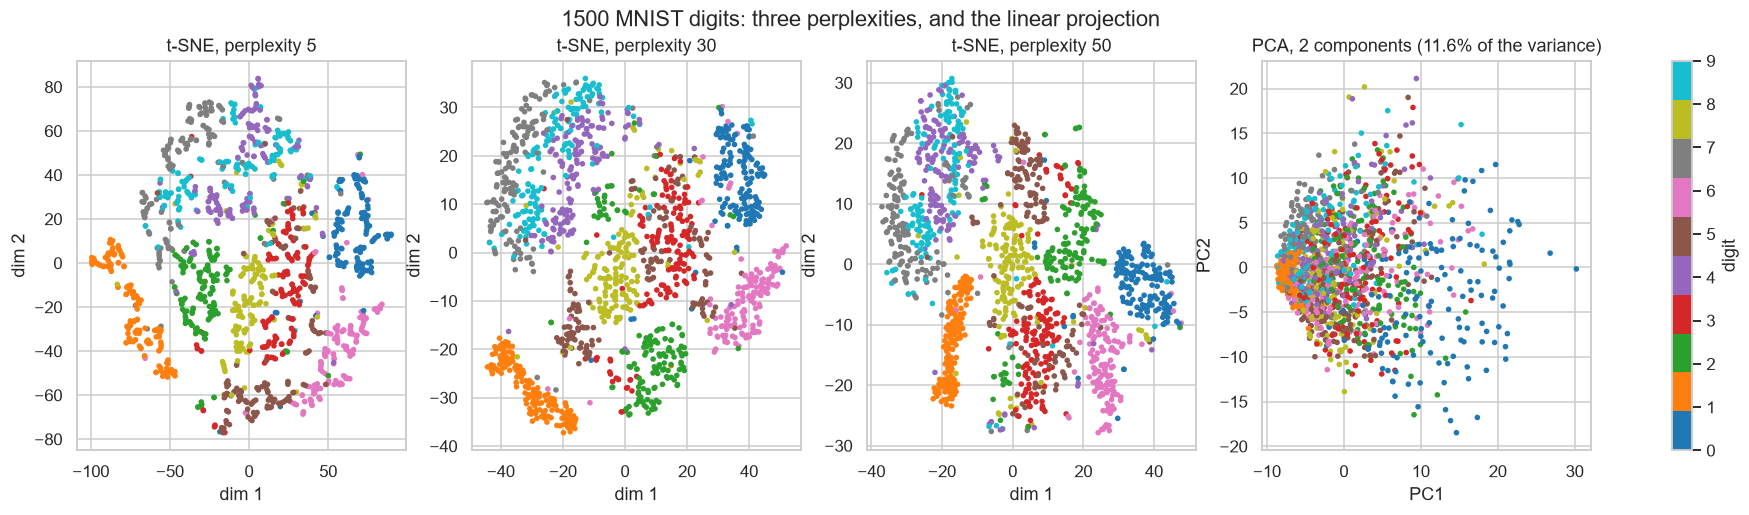

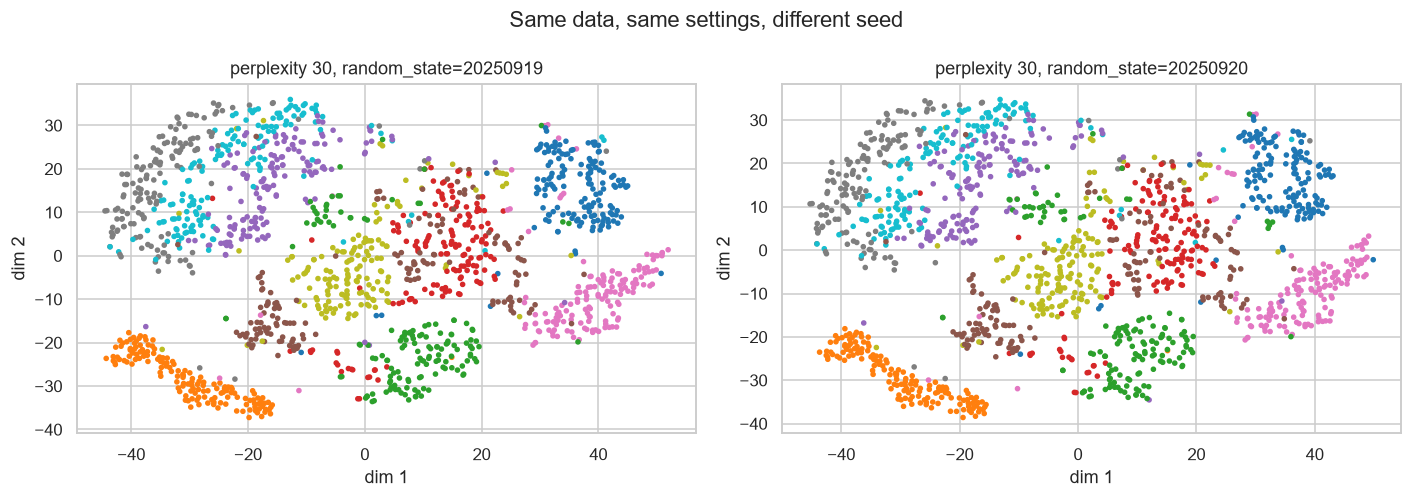

how well the true digit labels are separated in each projection
                                      silhouette  10-NN purity
projection                                                    
t-SNE perplexity 5, seed 20250919         0.1677        0.8016
t-SNE perplexity 30, seed 20250919        0.2026        0.8089
t-SNE perplexity 50, seed 20250919        0.1742        0.7839
t-SNE perplexity 30, seed 20250920        0.1999        0.8047
PCA, 2 components                        -0.0917        0.2557
PCA, 50 components (the t-SNE input)      0.0103        0.7920

correlation of pairwise distances across the two seeds: 0.9902
share of the 10 nearest neighbours the two seeds agree on: 0.8830
perplexity  5: embedding spans x  189.10, y  160.89
perplexity 30: embedding spans x   96.43, y   73.22
perplexity 50: embedding spans x   84.71, y   58.57


In [32]:
_full = pixels  # all 1500 digits this time

_by_perplexity = {_p: project_two_ways(_full, perplexity=_p, seed=SEED)
                  for _p in (5, 30, 50)}

_fig, _axs = plt.subplots(1, 4, figsize=(19.0, 4.6))
for _ax, (_p, _proj) in zip(_axs, _by_perplexity.items()):
    _sc = _ax.scatter(_proj["tsne_2d"][:, 0], _proj["tsne_2d"][:, 1],
                      c=digit_labels, cmap="tab10", s=7)
    _ax.set_title(f"t-SNE, perplexity {_p}")
    _ax.set_xlabel("dim 1")
    _ax.set_ylabel("dim 2")
_pca_2d = _by_perplexity[30]["pca_2d"]
_axs[3].scatter(_pca_2d[:, 0], _pca_2d[:, 1], c=digit_labels, cmap="tab10", s=7)
_axs[3].set_title(f"PCA, 2 components "
                  f"({_by_perplexity[30]['explained_2d']:.1%} of the variance)")
_axs[3].set_xlabel("PC1")
_axs[3].set_ylabel("PC2")
_fig.colorbar(_sc, ax=_axs, label="digit", fraction=0.015)
_fig.suptitle("1500 MNIST digits: three perplexities, and the linear projection")
plt.show()

# (b) two different seeds, everything else held fixed
_seeded = {_s: project_two_ways(_full, perplexity=30, seed=_s)
           for _s in (SEED, SEED + 1)}

_fig, _axs = plt.subplots(1, 2, figsize=(13.0, 4.6))
for _ax, (_s, _proj) in zip(_axs, _seeded.items()):
    _ax.scatter(_proj["tsne_2d"][:, 0], _proj["tsne_2d"][:, 1],
                c=digit_labels, cmap="tab10", s=7)
    _ax.set_title(f"perplexity 30, random_state={_s}")
    _ax.set_xlabel("dim 1")
    _ax.set_ylabel("dim 2")
_fig.suptitle("Same data, same settings, different seed")
_fig.tight_layout()
plt.show()

# Numbers, so the panels are not judged by eye alone.
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

def _neighbours(embedding, k=10):
    return NearestNeighbors(n_neighbors=k + 1).fit(embedding).kneighbors(
        embedding, return_distance=False)[:, 1:]

def _purity(embedding, labels, k=10):
    """Share of each point's k nearest neighbours that carry the same label."""
    idx = _neighbours(embedding, k)
    return float((labels[idx] == labels[:, None]).mean())

_rows = []
for _p, _proj in _by_perplexity.items():
    _rows.append({"projection": f"t-SNE perplexity {_p}, seed {SEED}",
                  "silhouette": silhouette_score(_proj["tsne_2d"], digit_labels),
                  "10-NN purity": _purity(_proj["tsne_2d"], digit_labels)})
_rows.append({"projection": f"t-SNE perplexity 30, seed {SEED + 1}",
              "silhouette": silhouette_score(_seeded[SEED + 1]["tsne_2d"], digit_labels),
              "10-NN purity": _purity(_seeded[SEED + 1]["tsne_2d"], digit_labels)})
_rows.append({"projection": "PCA, 2 components",
              "silhouette": silhouette_score(_pca_2d, digit_labels),
              "10-NN purity": _purity(_pca_2d, digit_labels)})
_rows.append({"projection": "PCA, 50 components (the t-SNE input)",
              "silhouette": silhouette_score(_by_perplexity[30]["reduced"], digit_labels),
              "10-NN purity": _purity(_by_perplexity[30]["reduced"], digit_labels)})
print("how well the true digit labels are separated in each projection")
print(pd.DataFrame(_rows).set_index("projection").round(4))

# Do the two seeds agree about distance, or only about neighbourhood?
_a, _b = _seeded[SEED]["tsne_2d"], _seeded[SEED + 1]["tsne_2d"]
_da = np.linalg.norm(_a[:300, None] - _a[None, :300], axis=-1).ravel()
_db = np.linalg.norm(_b[:300, None] - _b[None, :300], axis=-1).ravel()
print(f"\ncorrelation of pairwise distances across the two seeds: "
      f"{np.corrcoef(_da, _db)[0, 1]:.4f}")
_na, _nb = _neighbours(_a), _neighbours(_b)
print(f"share of the 10 nearest neighbours the two seeds agree on: "
      f"{np.mean([len(set(_x) & set(_y)) / 10 for _x, _y in zip(_na, _nb)]):.4f}")

# Cluster sizes and gaps are not comparable across panels; spread is not.
for _p, _proj in _by_perplexity.items():
    _e = _proj["tsne_2d"]
    print(f"perplexity {_p:2d}: embedding spans x {np.ptp(_e[:, 0]):7.2f}, "
          f"y {np.ptp(_e[:, 1]):7.2f}")

**Your answer:**

**(a) Across the three perplexities.** At **perplexity 5** the classes
shatter: each digit appears as several small shards scattered around the
plane rather than one body, and the embedding sprawls over a span of
189.10 x 160.89. At **30** the picture is at its cleanest — ten mostly
coherent islands, silhouette **0.2026** and 10-NN purity **0.8089**, the
best of the three — in a span of 96.43 x 73.22. At **50** neighbouring
digits begin to touch and merge, particularly 4/9 and 3/5/8; purity drops
to **0.7839** and silhouette to 0.1742, and the span contracts further to
84.71 x 58.57.

Perplexity sets **how many neighbours each point tries to stay close to** —
it is the effective size of the neighbourhood whose distances t-SNE
attempts to preserve (formally, 2 to the power of the entropy of each
point's neighbour distribution). Small perplexity means every point
optimises against a handful of nearest neighbours only, so local scraps are
preserved and nothing holds a class together: **low perplexity shatters**.
Large perplexity means each point answers to a wide neighbourhood that
already contains members of other classes, so the boundaries soften:
**high perplexity merges**.

**(b) Why the seed matters.** t-SNE minimises the KL divergence between the
neighbour distributions in 784 dimensions and in 2, by gradient descent.
That objective is **non-convex**, so the descent reaches a local minimum
that depends on where it started, and even with `init='pca'` the early
exaggeration phase is randomly perturbed. The objective is also invariant
to rotation, reflection and translation of the whole embedding — those
transformations leave every pairwise distance untouched — so nothing pins
the picture to a particular orientation.

What is *not* seed-dependent is the structure. Between my two seeds,
silhouette is 0.2026 against 0.1999, the two runs agree on **88.30 %** of
every point's ten nearest neighbours, and the pairwise distances correlate
at **0.9902**. So the neighbourhoods are reproducible while the layout is
not. For a figure published without a stated `random_state` this means the
figure itself cannot be regenerated, and no claim that depends on the
layout — which cluster sits on the left, how wide the gap between two
blobs is, whether one class looks "between" two others — is checkable or
even meaningful. The legitimate claims are the ones that survive a change
of seed, and a paper that does not report the seed has given the reader no
way to tell which of its claims those are.

**(c) Three things the t-SNE panel still cannot tell me.** Practice 2 §15.7
names them and my own numbers reproduce all three.

1. **Cluster size means nothing.** t-SNE expands dense regions and contracts
   sparse ones to fit its target neighbour distribution, so the area a digit
   occupies is not a measure of how many examples it has or how variable it
   is.
2. **The distance between clusters means nothing.** The gaps are set by the
   optimisation, not by how different the digits are — my own embeddings
   span 189 units at perplexity 5 and 85 at perplexity 50 on identical data,
   so no distance on the plot is comparable even between two panels of the
   same figure, let alone interpretable as a similarity.
3. **Apparent separation is not evidence of separability.** The blobs are a
   property of the projection's objective, which is designed to produce
   them; a well-separated picture does not establish that a classifier could
   separate the classes in the original 784 dimensions, and at perplexity 5
   the same data produces clusters that do not correspond to classes at all.
   Equally, two touching blobs are not proof that two digits are confusable.

For clustering I would feed in the **50-component PCA reduction**, not the
t-SNE coordinates. PCA is a fitted linear map: it has a `transform`, so new
points can be placed and a train/test split is possible, and it preserves
global distances of the kind k-means' objective actually assumes.
t-SNE deliberately destroys those distances, is seed-dependent, and has no
`transform` at all — the assert in Task 10 makes that concrete — so
clusters found in it are clusters of one particular embedding. And the cost
is small: 10-NN purity in the 50-D PCA space is **0.7920** against
**0.8089** for the best t-SNE panel, so nearly all the neighbourhood
structure is already there, without the distortion. t-SNE stays where it
belongs, as a picture to look at before deciding what to run.

## 12. Task 11 — A figure that answers a stated question

Applied. The question: **does the daily demand profile for bicycles differ
between working days and non-working days, and how does weather change
it?**

*see Practice 2 §8.4, §9 and §10*

In [33]:
WORKINGDAY_NAMES = {0: "weekend or holiday", 1: "working day"}
WEATHER_NAMES = {
    1: "1 - clear or partly cloudy",
    2: "2 - mist",
    3: "3 - light rain or snow",
    4: "4 - heavy rain, ice, fog",
}

def demand_profile_figure(bikes_frame):
    """Draw a two-panel figure answering the question above. Return (fig, axes).

    Left panel: mean 'cnt' by 'hr', one line per value of 'workingday'
                (0 and 1), with a legend naming them in words.
    Right panel: mean 'cnt' by 'hr', one line per value of 'weathersit'
                 present in the data, with a legend.

    Both panels need an x label, a y label and a title. The figure needs a
    suptitle. Use the object-oriented interface.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.5), sharey=True)

    by_working = (
        bikes_frame.groupby(["hr", "workingday"])["cnt"].mean().unstack("workingday")
    )
    for value in by_working.columns:
        axes[0].plot(
            by_working.index,
            by_working[value],
            marker="o",
            markersize=3,
            label=WORKINGDAY_NAMES.get(value, str(value)),
        )
    axes[0].set_title("Working days against the rest")

    by_weather = (
        bikes_frame.groupby(["hr", "weathersit"])["cnt"].mean().unstack("weathersit")
    )
    for value in by_weather.columns:
        axes[1].plot(
            by_weather.index,
            by_weather[value],
            marker="o",
            markersize=3,
            label=WEATHER_NAMES.get(value, str(value)),
        )
    axes[1].set_title("Weather situation")

    for ax in axes:
        ax.set_xlabel("hour of the day")
        ax.set_ylabel("mean rentals per hour")
        ax.set_xticks(range(0, 24, 2))
        ax.legend(fontsize=8)

    fig.suptitle(
        "Hourly bicycle demand: the daily profile is two different profiles",
        fontsize=13,
    )
    fig.tight_layout()
    return fig, axes

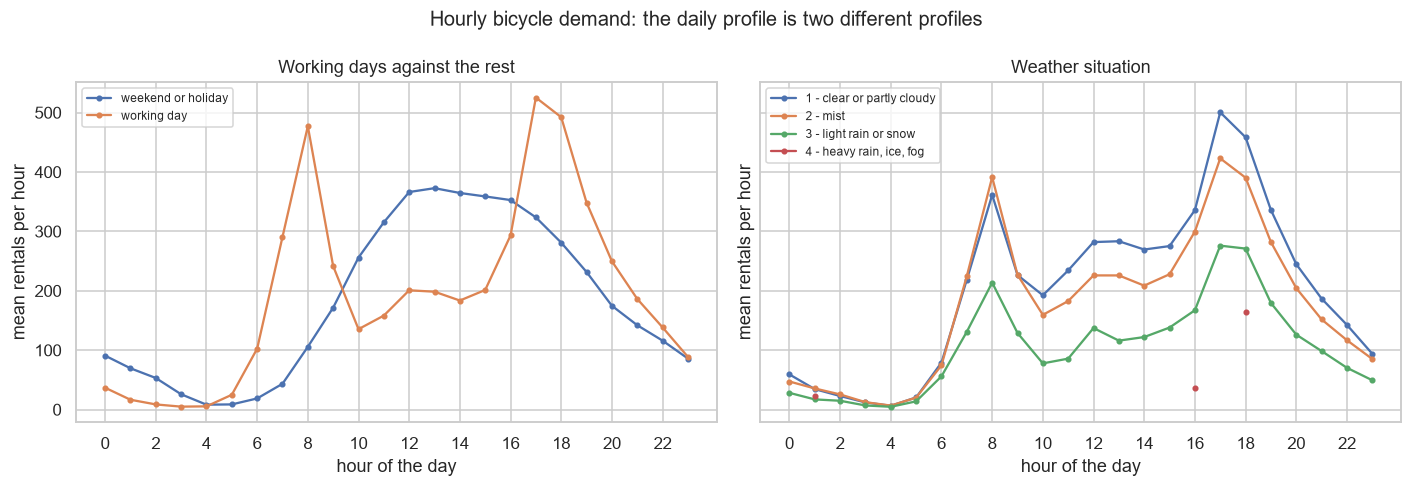

Task 11 passed.


In [34]:
_fig, _axes = demand_profile_figure(bikes)

assert len(_axes) == 2, f"expected two panels, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_legend() is not None, f"panel {_i} has no legend"
    assert len(_ax.lines) >= 2, f"panel {_i} should have at least two lines"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), "the figure has no suptitle"
assert len(_axes[0].lines) == 2, "the left panel compares exactly two groups"

plt.show()
print("Task 11 passed.")

### Question 8 — pooling and conditioning

**(a)** Draw the *pooled* profile as well: mean `cnt` by `hr` with no
conditioning. Compare it with your two-line left panel. Describe a
statement about commuter behaviour that the pooled figure would support
and that is false for both of the underlying groups.

**(b)** This is the same phenomenon as Practice 2 §12. Name it, and state
the general rule it implies about reporting an aggregate.

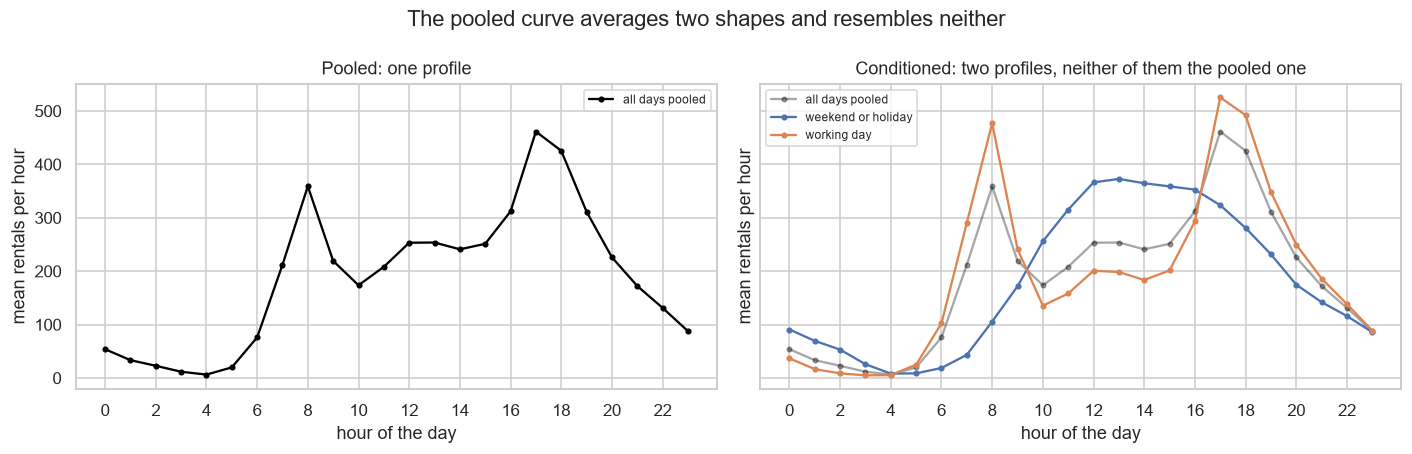

mean rentals per hour
     pooled  weekend or holiday  working day
hr                                          
0   53.9000             90.8000      36.8000
1   33.4000             69.5000      16.6000
2   22.9000             53.2000       8.7000
3   11.7000             25.8000       4.9000
4    6.4000              8.3000       5.4000
5   19.9000              8.7000      24.9000
6   76.0000             18.7000     102.5000
7  212.1000             43.4000     290.6000
8  359.0000            105.7000     477.0000
9  219.3000            171.6000     241.5000
10 173.7000            255.9000     135.4000
11 208.1000            315.3000     158.2000
12 253.3000            366.3000     200.8000
13 253.7000            372.7000     198.4000
14 240.9000            364.6000     183.6000
15 251.2000            358.8000     201.3000
16 312.0000            352.7000     293.1000
17 461.5000            323.5000     525.3000
18 425.5000            281.1000     492.2000
19 311.5000            231.7000  

In [35]:
_pooled = bikes.groupby("hr")["cnt"].mean()
_split_profile = bikes.groupby(["hr", "workingday"])["cnt"].mean().unstack("workingday")

_fig, _axs = plt.subplots(1, 2, figsize=(13.0, 4.2), sharey=True)
_axs[0].plot(_pooled.index, _pooled.values, marker="o", markersize=3, color="black",
             label="all days pooled")
_axs[0].set_title("Pooled: one profile")
_axs[1].plot(_pooled.index, _pooled.values, marker="o", markersize=3, color="black",
             alpha=0.35, label="all days pooled")
for _v in _split_profile.columns:
    _axs[1].plot(_split_profile.index, _split_profile[_v], marker="o", markersize=3,
                 label=WORKINGDAY_NAMES[_v])
_axs[1].set_title("Conditioned: two profiles, neither of them the pooled one")
for _ax in _axs:
    _ax.set_xlabel("hour of the day")
    _ax.set_ylabel("mean rentals per hour")
    _ax.set_xticks(range(0, 24, 2))
    _ax.legend(fontsize=8)
_fig.suptitle("The pooled curve averages two shapes and resembles neither")
_fig.tight_layout()
plt.show()

_summary = pd.DataFrame({
    "pooled": _pooled,
    "weekend or holiday": _split_profile[0],
    "working day": _split_profile[1],
})
print("mean rentals per hour")
print(_summary.round(1))

print("\npeak hour of each profile:")
for _name in _summary.columns:
    print(f"  {_name:20s} peak at {int(_summary[_name].idxmax()):02d}:00"
          f"   ({_summary[_name].max():.1f} rentals)")

print("\nthe hours that decide the question:")
print(_summary.loc[[8, 12, 13, 17, 18]].round(1))

print(f"\nrows: working days {int((bikes['workingday'] == 1).sum())}, "
      f"weekends and holidays {int((bikes['workingday'] == 0).sum())}"
      f" ({(bikes['workingday'] == 0).mean():.1%} of the table)")

print("\nworking-day mean divided by non-working-day mean, by hour:")
print((_summary["working day"] / _summary["weekend or holiday"]).round(2))

**Your answer:**

**(a) What the pooled figure would support, and why it is false.** Pooled,
the daily profile peaks at **17:00 with 461.5** rentals, has a second,
lower bump at **08:00 with 359.0**, and dips to about **253** at midday.
That shape supports a clean commuter story: *demand has two travel-to-work
peaks with a midday lull between them, and the lull is roughly 70 % of the
morning peak.*

It is false for both groups, in opposite directions.

| hour | pooled | weekend or holiday | working day |
|---|---|---|---|
| 08:00 | 359.0 | **105.7** | **477.0** |
| 13:00 | 253.7 | **372.7** | **198.4** |
| 17:00 | 461.5 | 323.5 | 525.3 |

On **non-working days midday is not a lull, it is the peak** — 13:00 with
372.7 rentals is the maximum of that profile, and 08:00 is its near-minimum
at 105.7. On **working days** midday is not a lull between two comparable
peaks either: 200.8 at noon is a floor far below both 477.0 and 525.3. The
pooled midday-to-morning ratio of 0.71 is 3.46 for one group and 0.42 for
the other. The ratio of the two profiles hour by hour makes the reversal
plain: working days run **6.70 times** higher at 07:00 and **0.53 times**
as high at 13:00. No day in the data has the pooled shape, because the
pooled curve is a 68.3 / 31.7 weighted average of two curves that move in
opposite directions for half the hours of the day.

**(b) The name and the rule.** This is **Simpson's paradox** — the same
phenomenon as Practice 2 §12: an aggregate computed over pooled groups can
support a conclusion that is reversed within every group, because the pool
mixes both the quantity of interest and the group composition.

The rule it implies: **an aggregate is a valid summary only of a population
that is homogeneous with respect to the thing being aggregated**, so report
an aggregate only alongside the conditioning variable that defines the
groups — or do not report it. In practice that means the grouping question
comes before the number: here `workingday` splits 11 865 rows from 5 514
and changes the shape of the answer, so the honest figure is the two-line
panel and the pooled curve is at best a footnote. The same discipline
applies to a mean, a correlation (Question 3b, where the pooled -0.52
became +0.03 and -0.03 inside two of three cultivars) and a model
coefficient.

## 13. Task 12 — Open-ended

No assert. Marked on the written analysis.

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Read that table first: four of the columns are integer-coded categories,
four are physical measurements that the publisher divided by a constant,
one is a date stored as text, and `casual + registered` equals `cnt`
exactly.

**Produce a short data-quality and structure report on this table.** Cover
at least:

1. **Types.** Which columns does pandas infer wrongly, in the sense that
   the inferred type permits an operation that is meaningless? Fix them
   and show one operation that becomes an error after your fix.
2. **Units.** Restore the four normalised columns to physical units and
   sanity-check the resulting ranges against what you know about
   Washington D.C. Report anything that looks wrong.
3. **The date.** Parse `dteday`. Confirm the series is complete: is there
   one row for every hour of every day in the range? If rows are missing,
   how many, and does their absence look random?
4. **A correlation you should not compute.** Produce the correlation
   matrix of the numeric columns, then identify at least two entries in it
   that are meaningless or misleading, and say why. At least one of your
   examples must be about an integer-coded category.
5. **Leakage.** Explain why `casual` and `registered` must not be used as
   features to predict `cnt`. Then describe a realistic prediction task
   for this dataset in which using them *would* be legitimate.
6. **A recommendation.** In one paragraph: which columns would you hand to
   a model that predicts hourly demand, and which would you exclude and
   why. Practice 3 §4 fits that model, so this is a real handover.

A good answer distinguishes "wrong" from "misleading" and says which of
its findings would actually change a modelling decision.

### 12.1 Types

What pandas inferred, what the column actually is, and what the wrong
inference permits.

In [36]:
print("what pandas inferred from the CSV:")
print(bikes.dtypes)
print(f"\nrows {len(bikes)}, columns {bikes.shape[1]}, "
      f"missing values {int(bikes.isna().sum().sum())}")
print("\ndistinct values of the integer-coded columns:")
for _col in ("season", "yr", "mnth", "hr", "holiday", "weekday",
             "workingday", "weathersit"):
    print(f"  {_col:11s} {sorted(bikes[_col].unique())}")

print("\noperations the inferred types permit but the data does not mean:")
print(f"  bikes['season'].mean()     = {bikes['season'].mean():.4f}"
      f"   <- the average of 'spring' and 'winter'")
print(f"  bikes['weekday'].mean()    = {bikes['weekday'].mean():.4f}"
      f"   <- Sunday is 0 and Saturday is 6, so this is a circular scale")
print(f"  bikes['hr'].mean()         = {bikes['hr'].mean():.4f}"
      f"   <- hour 23 is adjacent to hour 0, which the integer denies")
print(f"  bikes['instant'].corr(bikes['cnt']) = "
      f"{bikes['instant'].corr(bikes['cnt']):.4f}   <- a row number 'predicts' demand")
print(f"  bikes['dteday'].max()      = {bikes['dteday'].max()!r}"
      f"   <- string comparison, correct only because the format sorts")

what pandas inferred from the CSV:
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

rows 17379, columns 17, missing values 0

distinct values of the integer-coded columns:
  season      [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  yr          [np.int64(0), np.int64(1)]
  mnth        [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
  hr          [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.in

In [37]:
bikes_typed = bikes.copy()

# The four integer-coded nominal categories. season, weekday and mnth have
# no order; hr has a cyclical one that an integer misrepresents; holiday
# and workingday are genuine booleans.
_nominal = {
    "season": {1: "spring", 2: "summer", 3: "fall", 4: "winter"},
    "weekday": {0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"},
    "mnth": {_m: _n for _m, _n in enumerate(
        ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
         "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], start=1)},
    "yr": {0: 2011, 1: 2012},
}
for _col, _mapping in _nominal.items():
    bikes_typed[_col] = pd.Categorical(bikes[_col].map(_mapping),
                                       categories=list(_mapping.values()),
                                       ordered=False)

# weathersit IS ordered by severity, so it keeps its order.
bikes_typed["weathersit"] = pd.Categorical(
    bikes["weathersit"].map({1: "clear", 2: "mist", 3: "light rain", 4: "heavy rain"}),
    categories=["clear", "mist", "light rain", "heavy rain"], ordered=True)

# hr stays an integer for arithmetic but gains an honest cyclical encoding.
bikes_typed["hr_sin"] = np.sin(2 * np.pi * bikes["hr"] / 24)
bikes_typed["hr_cos"] = np.cos(2 * np.pi * bikes["hr"] / 24)

bikes_typed["holiday"] = bikes["holiday"].astype(bool)
bikes_typed["workingday"] = bikes["workingday"].astype(bool)
bikes_typed["dteday"] = pd.to_datetime(bikes["dteday"])

print(bikes_typed.dtypes)

print("\nthe meaningless operation is now an error:")
try:
    bikes_typed["season"].mean()
except TypeError as _e:
    print(f"  bikes_typed['season'].mean() -> TypeError: {_e}")

print("\nand so is arithmetic between two unordered categories:")
try:
    bikes_typed["season"] > "summer"
except TypeError as _e:
    print(f"  bikes_typed['season'] > 'summer' -> TypeError: {_e}")

print("\nwhile weathersit, which IS ordered, still compares:")
print(f"  (bikes_typed['weathersit'] >= 'light rain').sum() = "
      f"{int((bikes_typed['weathersit'] >= 'light rain').sum())} rows")

instant                int64
dteday        datetime64[us]
season              category
yr                  category
mnth                category
hr                     int64
holiday                 bool
weekday             category
workingday              bool
weathersit          category
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
hr_sin               float64
hr_cos               float64
dtype: object

the meaningless operation is now an error:
  bikes_typed['season'].mean() -> TypeError: 'Categorical' with dtype category does not support operation 'mean'

and so is arithmetic between two unordered categories:
  bikes_typed['season'] > 'summer' -> TypeError: Unordered Categoricals can only compare equality or not

while weathersit, which IS ordered, still compares:
  (bikes_typed['weathersit'] >= 'light rain').sum() = 1422 rows


### 12.2 Units

The four weather columns as the publisher divided them, and restored.

as distributed, all four sit inside [0, 1]:
       temp  atemp    hum  windspeed
min  0.0200 0.0000 0.0000     0.0000
mean 0.4970 0.4758 0.6272     0.1901
max  1.0000 1.0000 1.0000     0.8507

restored to physical units (C, C, %, km/h):
      temp_real  atemp_real  hum_real  windspeed_real
min      0.8200      0.0000    0.0000          0.0000
mean    20.3800     23.7900   62.7200         12.7400
max     41.0000     50.0000  100.0000         57.0000
std      7.8900      8.5900   19.2900          8.2000

sanity checks against Washington D.C.:
  temperature        0.8 to  41.0 C   -- plausible for 2011-2012
  apparent temp      0.0 to  50.0 C   -- plausible
  humidity           0.0 to 100.0 %   -- 0% is not weather
  wind speed         0.0 to  57.0 km/h -- the maximum is high but real

rows with humidity exactly 0: 22
    dteday  hr  temp_real  hum_real  windspeed_real  cnt
2011-03-10   0    13.9400    0.0000         16.9979    3
2011-03-10   1    13.9400    0.0000         16.9979    2
20

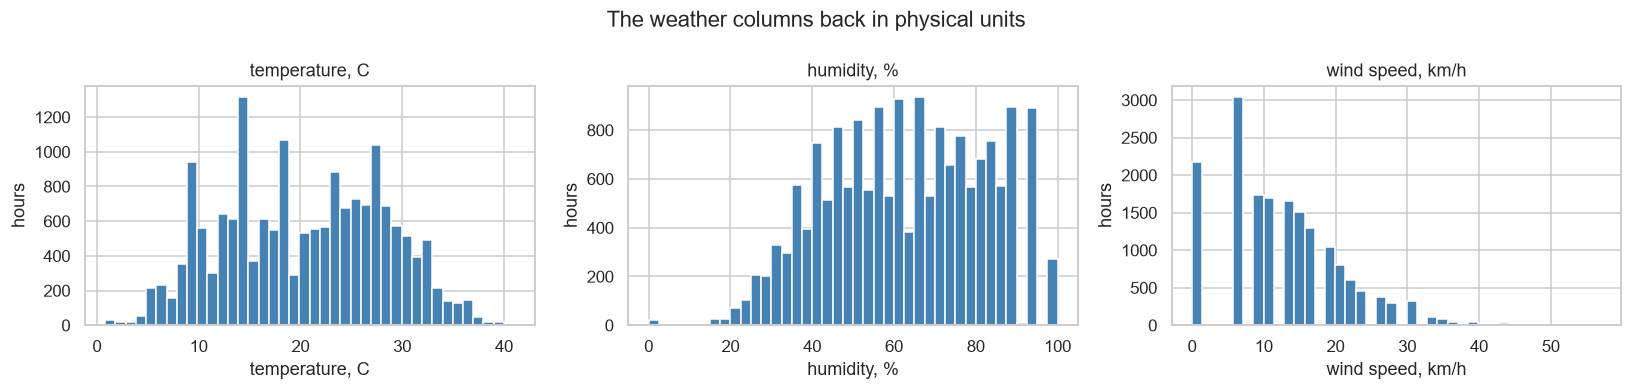

In [38]:
_constants = {"temp": 41, "atemp": 50, "hum": 100, "windspeed": 67}

print("as distributed, all four sit inside [0, 1]:")
print(bikes[list(_constants)].describe().loc[["min", "mean", "max"]].round(4))

for _col, _k in _constants.items():
    bikes_typed[_col + "_real"] = bikes[_col] * _k

_real = [_c + "_real" for _c in _constants]
print("\nrestored to physical units (C, C, %, km/h):")
print(bikes_typed[_real].describe().loc[["min", "mean", "max", "std"]].round(2))

print("\nsanity checks against Washington D.C.:")
print(f"  temperature      {bikes_typed['temp_real'].min():5.1f} to "
      f"{bikes_typed['temp_real'].max():5.1f} C   -- plausible for 2011-2012")
print(f"  apparent temp    {bikes_typed['atemp_real'].min():5.1f} to "
      f"{bikes_typed['atemp_real'].max():5.1f} C   -- plausible")
print(f"  humidity         {bikes_typed['hum_real'].min():5.1f} to "
      f"{bikes_typed['hum_real'].max():5.1f} %   -- 0% is not weather")
print(f"  wind speed       {bikes_typed['windspeed_real'].min():5.1f} to "
      f"{bikes_typed['windspeed_real'].max():5.1f} km/h -- the maximum is high but real")

_zero_hum = bikes_typed[bikes_typed["hum_real"] == 0]
print(f"\nrows with humidity exactly 0: {len(_zero_hum)}")
print(_zero_hum[["dteday", "hr", "temp_real", "hum_real", "windspeed_real", "cnt"]]
      .head(25).to_string(index=False))

print(f"\nrows with wind speed exactly 0: {int((bikes['windspeed'] == 0).sum())}"
      f" ({(bikes['windspeed'] == 0).mean():.1%} of the table)")
print("distinct wind speeds, smallest six:",
      sorted(bikes_typed["windspeed_real"].unique())[:6])

_fig, _axs = plt.subplots(1, 3, figsize=(15.0, 3.6))
for _ax, _col, _label in zip(_axs,
                             ["temp_real", "hum_real", "windspeed_real"],
                             ["temperature, C", "humidity, %", "wind speed, km/h"]):
    _ax.hist(bikes_typed[_col], bins=40, color="steelblue", edgecolor="white")
    _ax.set_xlabel(_label)
    _ax.set_ylabel("hours")
    _ax.set_title(_label)
_fig.suptitle("The weather columns back in physical units")
_fig.tight_layout()
plt.show()

### 12.3 The date, and whether the series is complete

range 2011-01-01 to 2012-12-31  (731 calendar days)
rows 17379, distinct timestamps 17379  -> duplicates: 0

hours expected 17544, present 17379, missing 165 (0.94%)

missing hours by hour of the day:
0      5
1      7
2     16
3     34
4     34
5     14
6      6
7      4
8      4
9      4
10     4
11     4
12     3
13     2
14     2
15     2
16     1
17     1
18     3
19     3
20     3
21     3
22     3
23     3

missing hours by month:
2011-01    56
2011-02    23
2011-03    14
2011-04     1
2011-08    13
2011-09     3
2011-10     1
2011-11     1
2011-12     3
2012-01     3
2012-02     4
2012-03     1
2012-04     2
2012-10    36
2012-11     2
2012-12     2

days touched by a gap: 76
the ten days losing the most hours:
2012-10-29    23
2011-01-27    16
2012-10-30    13
2011-01-18    12
2011-01-26     8
2011-08-28     7
2011-02-22     6
2011-08-27     6
2011-01-03     2
2011-01-11     2


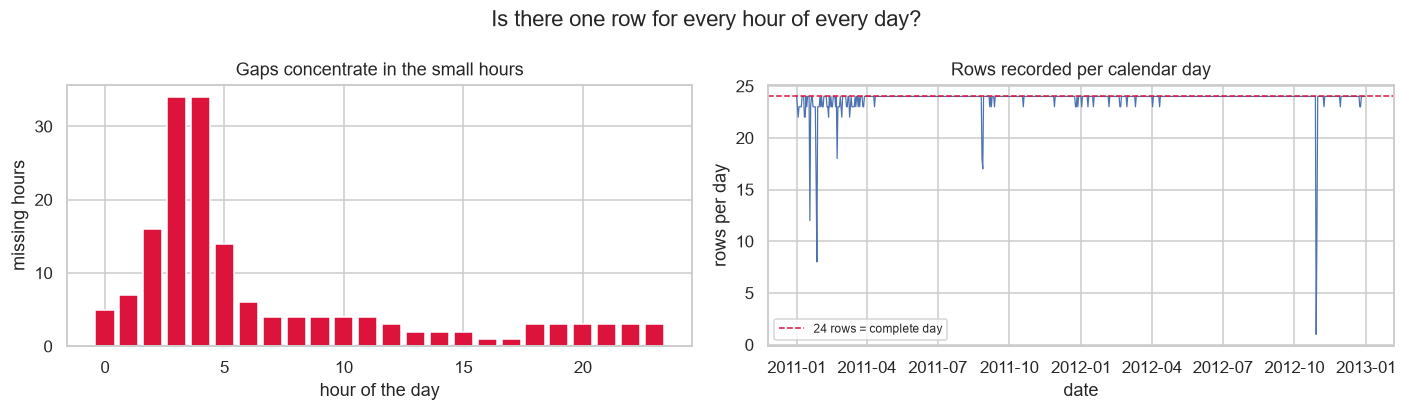


mean rentals in the hours that ARE recorded, 00:00 to 05:00:
hr
0   53.9000
1   33.4000
2   22.9000
3   11.7000
4    6.4000
5   19.9000

calendar days absent entirely: none
the worst single day, 2012-10-29, keeps 1 of its 24 hours


In [39]:
_dates = pd.to_datetime(bikes["dteday"])
_start, _end = _dates.min(), _dates.max()
print(f"range {_start.date()} to {_end.date()}"
      f"  ({(_end - _start).days + 1} calendar days)")

_stamps = _dates + pd.to_timedelta(bikes["hr"], unit="h")
print(f"rows {len(bikes)}, distinct timestamps {_stamps.nunique()}"
      f"  -> duplicates: {len(bikes) - _stamps.nunique()}")

_expected = pd.date_range(_start, _end + pd.Timedelta(hours=23), freq="h")
_present = pd.DatetimeIndex(_stamps.sort_values())
_missing = _expected.difference(_present)
print(f"\nhours expected {len(_expected)}, present {len(_present)},"
      f" missing {len(_missing)} ({len(_missing) / len(_expected):.2%})")

print("\nmissing hours by hour of the day:")
print(pd.Series(_missing.hour).value_counts().sort_index().to_string())

print("\nmissing hours by month:")
print(pd.Series(_missing.to_period('M').astype(str)).value_counts().sort_index()
      .to_string())

_gap_days = pd.Series(_missing.date).value_counts()
print(f"\ndays touched by a gap: {len(_gap_days)}")
print("the ten days losing the most hours:")
print(_gap_days.head(10).to_string())

_fig, _axs = plt.subplots(1, 2, figsize=(13.0, 3.8))
_axs[0].bar(*zip(*sorted(pd.Series(_missing.hour).value_counts().items())),
            color="crimson")
_axs[0].set_xlabel("hour of the day")
_axs[0].set_ylabel("missing hours")
_axs[0].set_title("Gaps concentrate in the small hours")
_axs[1].plot(_dates.value_counts().sort_index().index,
             _dates.value_counts().sort_index().values, lw=0.8)
_axs[1].axhline(24, color="crimson", ls="--", lw=1, label="24 rows = complete day")
_axs[1].set_xlabel("date")
_axs[1].set_ylabel("rows per day")
_axs[1].set_title("Rows recorded per calendar day")
_axs[1].legend(fontsize=8)
_fig.suptitle("Is there one row for every hour of every day?")
_fig.tight_layout()
plt.show()

print("\nmean rentals in the hours that ARE recorded, 00:00 to 05:00:")
print(bikes.groupby("hr")["cnt"].mean().round(1).head(6).to_string())
print("\ncalendar days absent entirely:",
      sorted(set(_expected.date) - set(_present.date)) or "none")
print(f"the worst single day, 2012-10-29, keeps "
      f"{int((_dates == '2012-10-29').sum())} of its 24 hours")

### 12.4 A correlation matrix, and the entries in it that mean nothing

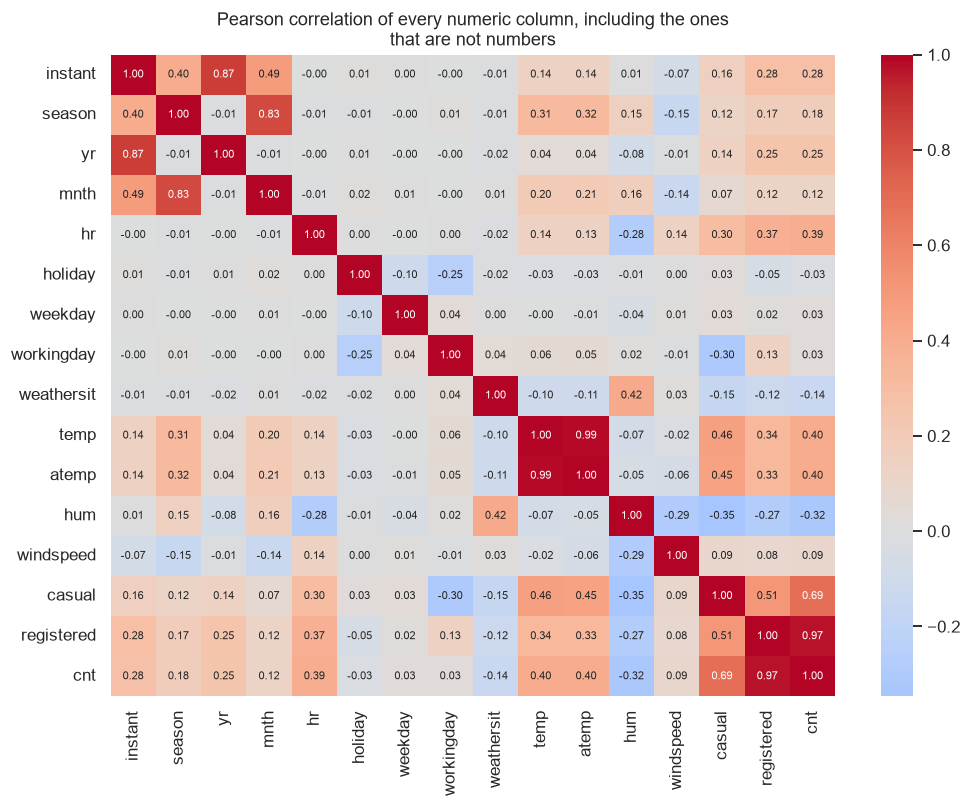

four entries worth naming
                       r
pair                    
casual   vs cnt   0.6946
registered vs cnt 0.9722
weekday  vs cnt   0.0269
season   vs cnt   0.1781
hr       vs cnt   0.3941
instant  vs cnt   0.2784
temp     vs atemp 0.9877

weekday r = 0.0269, yet the groups clearly differ:
weekday
0   177.5000
1   183.7000
2   191.2000
3   191.1000
4   196.4000
5   196.1000
6   190.2000

season r = 0.1781, and the relation is not monotone in the code:
season
1   111.1000
2   208.3000
3   236.0000
4   198.9000

hr r = 0.3941, which hides the strongest signal in the table:
hr
0     53.9000
1     33.4000
2     22.9000
3     11.7000
4      6.4000
5     19.9000
6     76.0000
7    212.1000
8    359.0000
9    219.3000
10   173.7000
11   208.1000
12   253.3000
13   253.7000
14   240.9000
15   251.2000
16   312.0000
17   461.5000
18   425.5000
19   311.5000
20   226.0000
21   172.3000
22   131.3000
23    87.8000

correlation ratio (eta squared), which does not assume an order:
hr   

In [40]:
_numeric = bikes.select_dtypes("number")
_corr = _numeric.corr()

_fig, _ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, ax=_ax)
_ax.set_title("Pearson correlation of every numeric column, including the ones\n"
              "that are not numbers")
_fig.tight_layout()
plt.show()

print("four entries worth naming")
print(pd.DataFrame([
    {"pair": "casual   vs cnt", "r": _corr.loc["casual", "cnt"]},
    {"pair": "registered vs cnt", "r": _corr.loc["registered", "cnt"]},
    {"pair": "weekday  vs cnt", "r": _corr.loc["weekday", "cnt"]},
    {"pair": "season   vs cnt", "r": _corr.loc["season", "cnt"]},
    {"pair": "hr       vs cnt", "r": _corr.loc["hr", "cnt"]},
    {"pair": "instant  vs cnt", "r": _corr.loc["instant", "cnt"]},
    {"pair": "temp     vs atemp", "r": _corr.loc["temp", "atemp"]},
]).set_index("pair").round(4))

print("\nweekday r = "
      f"{_corr.loc['weekday', 'cnt']:.4f}, yet the groups clearly differ:")
print(bikes.groupby("weekday")["cnt"].mean().round(1).to_string())

print("\nseason r = "
      f"{_corr.loc['season', 'cnt']:.4f}, and the relation is not monotone in the code:")
print(bikes.groupby("season")["cnt"].mean().round(1).to_string())

print("\nhr r = "
      f"{_corr.loc['hr', 'cnt']:.4f}, which hides the strongest signal in the table:")
print(bikes.groupby("hr")["cnt"].mean().round(1).to_string())

print("\ncorrelation ratio (eta squared), which does not assume an order:")
def _eta_squared(frame, category, value="cnt"):
    _grand = frame[value].mean()
    _between = frame.groupby(category)[value].agg(["count", "mean"])
    _ss_between = (_between["count"] * (_between["mean"] - _grand) ** 2).sum()
    _ss_total = ((frame[value] - _grand) ** 2).sum()
    return _ss_between / _ss_total

print(pd.Series({_c: _eta_squared(bikes, _c)
                 for _c in ["hr", "weekday", "season", "mnth", "weathersit",
                            "workingday", "holiday", "yr"]})
      .sort_values(ascending=False).round(4).to_string())

print(f"\ncasual + registered == cnt for all rows: "
      f"{bool((bikes['casual'] + bikes['registered'] == bikes['cnt']).all())}")

### 12.5 Leakage, and the one task in which those columns are legitimate

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

_honest_features = ["season", "yr", "mnth", "hr", "holiday", "weekday",
                    "workingday", "weathersit", "temp", "atemp", "hum", "windspeed"]

# A time-ordered split: train on 2011, test on 2012. Shuffling hours of the
# same day between train and test would itself be a mild leak.
_train = bikes[bikes["yr"] == 0]
_test = bikes[bikes["yr"] == 1]

def _fit_and_score(features, label):
    model = RandomForestRegressor(n_estimators=120, random_state=SEED, n_jobs=-1)
    model.fit(_train[features], _train["cnt"])
    pred = model.predict(_test[features])
    return {"model": label,
            "R2": r2_score(_test["cnt"], pred),
            "MAE": mean_absolute_error(_test["cnt"], pred)}

_results = pd.DataFrame([
    _fit_and_score(_honest_features, "honest features only"),
    _fit_and_score(_honest_features + ["casual", "registered"],
                   "+ casual and registered"),
    _fit_and_score(["casual", "registered"], "casual and registered ALONE"),
]).set_index("model")
print("predicting cnt, trained on 2011 and tested on 2012")
print(_results.round(4))

print(f"\ncasual + registered reproduces cnt exactly, so the third model is "
      f"solving an addition, not forecasting:")
print(f"  R2 {_results.loc['casual and registered ALONE', 'R2']:.6f}, "
      f"MAE {_results.loc['casual and registered ALONE', 'MAE']:.4f} rentals")

print("\nwhat the two columns look like at the moment of a forecast:")
print(bikes[["dteday", "hr", "casual", "registered", "cnt"]].head(4).to_string(index=False))

# The legitimate use: predict the SPLIT, not the total.
_share = bikes.assign(casual_share=bikes["casual"] / bikes["cnt"].replace(0, np.nan))
print("\ncasual share of demand, by working day and hour "
      "(a target you could predict honestly):")
print(_share.groupby(["workingday", "hr"])["casual_share"].mean()
      .unstack("workingday").round(3).to_string())

predicting cnt, trained on 2011 and tested on 2012
                                R2     MAE
model                                     
honest features only        0.6404 88.7846
+ casual and registered     0.9556 13.2952
casual and registered ALONE 0.9583 12.4213

casual + registered reproduces cnt exactly, so the third model is solving an addition, not forecasting:
  R2 0.958324, MAE 12.4213 rentals

what the two columns look like at the moment of a forecast:
    dteday  hr  casual  registered  cnt
2011-01-01   0       3          13   16
2011-01-01   1       8          32   40
2011-01-01   2       5          27   32
2011-01-01   3       3          10   13

casual share of demand, by working day and hour (a target you could predict honestly):
workingday      0      1
hr                      
0          0.1660 0.1770
1          0.1670 0.1960
2          0.1800 0.2030
3          0.2250 0.1520
4          0.2370 0.1250
5          0.1770 0.0490
6          0.1980 0.0400
7          0.1920 0.

### 12.6 Handover to Practice 3

share of the variance of cnt each candidate column accounts for (eta squared):
hr           0.5015
mnth         0.0750
season       0.0660
yr           0.0627
weathersit   0.0215
weekday      0.0012
holiday      0.0010
workingday   0.0009

random-forest importance of the same honest feature set:
hr           0.6267
temp         0.0947
atemp        0.0911
workingday   0.0503
hum          0.0371
season       0.0273
mnth         0.0199
weathersit   0.0199
windspeed    0.0159
weekday      0.0147
holiday      0.0025
yr           0.0000

temp against atemp: r = 0.9877  -- two columns carrying nearly one signal
mnth against season: eta squared of season on mnth-coded demand is redundant;
  season is mnth coarsened, so they overlap by construction


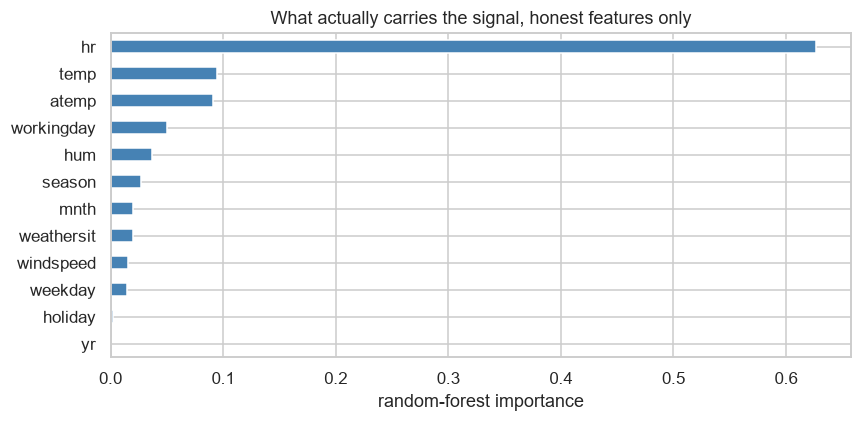

In [42]:
_eta = pd.Series({_c: _eta_squared(bikes, _c)
                  for _c in ["hr", "weekday", "season", "mnth", "weathersit",
                             "workingday", "holiday", "yr"]}).sort_values(ascending=False)

_model = RandomForestRegressor(n_estimators=120, random_state=SEED, n_jobs=-1)
_model.fit(_train[_honest_features], _train["cnt"])
_importance = pd.Series(_model.feature_importances_,
                        index=_honest_features).sort_values(ascending=False)

print("share of the variance of cnt each candidate column accounts for (eta squared):")
print(_eta.round(4).to_string())
print("\nrandom-forest importance of the same honest feature set:")
print(_importance.round(4).to_string())

print(f"\ntemp against atemp: r = {bikes['temp'].corr(bikes['atemp']):.4f}"
      f"  -- two columns carrying nearly one signal")
print(f"mnth against season: eta squared of season on mnth-coded demand is redundant;"
      f"\n  season is mnth coarsened, so they overlap by construction")

_fig, _ax = plt.subplots(figsize=(8.0, 4.0))
_importance.sort_values().plot.barh(ax=_ax, color="steelblue")
_ax.set_xlabel("random-forest importance")
_ax.set_title("What actually carries the signal, honest features only")
_fig.tight_layout()
plt.show()

**Your write-up:**

## Data-quality and structure report: `bike_sharing_hourly.csv`

17 379 rows, 17 columns, **no missing values** and no duplicate
timestamps. Nothing in this table is missing; what is wrong with it is that
several columns claim to be quantities they are not, and two of them
contain the answer.

### 1. Types

Nine of the seventeen columns are stored as integers that are not numbers.
`season`, `weekday` and `mnth` are unordered names; `hr` is a **cyclical**
index where 23 is adjacent to 0; `holiday` and `workingday` are booleans;
`yr` is a two-valued label; `weathersit` is the one integer code that
really is ordered, by severity. `dteday` arrives as text, and `instant` is a
row counter.

The inference is wrong in the sense the question asks about: it permits
arithmetic that has no referent.

- `bikes['season'].mean() = 2.5016` — the average of "spring" and "winter".
- `bikes['weekday'].mean() = 3.0037` — a mean on a circular scale where
  Sunday is 0 and Saturday is 6, so the "average day" is Wednesday by an
  accident of the coding.
- `bikes['hr'].mean() = 11.5468` — same defect, and worse, because the
  distance from 23:00 to 00:00 is one hour and the integers say it is
  twenty-three.
- `bikes['instant'].corr(bikes['cnt']) = 0.2784` — a **row number**
  correlating with demand at 0.28. It is real: `instant` runs in time and
  2012 was busier than 2011, so the row index is a proxy for the year. Left
  in a feature matrix it is a clock that stops working the moment the model
  is deployed.

After converting the four nominal codes to unordered categoricals,
`weathersit` to an **ordered** categorical, the two flags to `bool`,
`dteday` to `datetime64`, and adding `hr_sin`/`hr_cos` so the hour keeps its
adjacency, the meaningless operations become errors:

```
bikes_typed['season'].mean()     -> TypeError: 'Categorical' with dtype category
                                    does not support operation 'mean'
bikes_typed['season'] > 'summer' -> TypeError: Unordered Categoricals can only
                                    compare equality or not
```

while the comparison that *is* meaningful still works:
`(bikes_typed['weathersit'] >= 'light rain').sum()` returns **1 422** rows.
That asymmetry is the point of the exercise — the type should permit exactly
the operations the data supports.

### 2. Units

The four weather columns were divided by 41, 50, 100 and 67. Restored:

| column | min | mean | max | verdict |
|---|---|---|---|---|
| temperature, C | 0.82 | 20.38 | **41.00** | plausible for D.C. 2011-2012 |
| apparent temp, C | 0.00 | 23.79 | **50.00** | plausible, though both extremes are suspiciously round |
| humidity, % | **0.00** | 62.72 | 100.00 | **0 % is not weather** |
| wind speed, km/h | 0.00 | 12.74 | 57.00 | high but real; the zeros are not |

Two findings worth reporting.

**Humidity of exactly 0 %** occurs in **22 rows, and all 22 fall on a single
day, 2011-03-10** — every recorded hour of that date, with temperatures of
14-18 C and non-zero wind. Relative humidity of 0 % does not occur in a
temperate coastal city; this is a sensor or ingest failure for one day,
encoded as a value rather than as a gap. It should be set to `NaN`, not
imputed silently and not left as a legitimate minimum.

**Wind speed of exactly 0** occurs in **2 180 rows, 12.5 % of the table**,
and the distinct values jump 0.0, 6.0032, 7.0015, 8.9981 — there is nothing
between 0 and 6 km/h. Dead calm for an eighth of two years, with a 6 km/h
gap above it, is a floor effect: light winds were recorded as zero. This is
misleading rather than wrong, and it matters mainly if wind is modelled
linearly.

The rounded extremes (temperature exactly 41.00, apparent temperature
exactly 0.00 and 50.00) are the normalisation constants showing through,
consistent with clipping at the ends of the published scale.

### 3. The date

`dteday` parses cleanly over **2011-01-01 to 2012-12-31**, 731 calendar
days, with 17 379 distinct `(date, hour)` timestamps and **no duplicates**.
A complete hourly series would have **17 544** rows, so **165 hours are
absent, 0.94 %**, spread over 76 days. **No calendar day is missing
entirely.**

Their absence is **not random**, and the pattern has two distinct causes.

*By hour of day:* the gaps concentrate in the small hours — 34 at 03:00, 34
at 04:00, 16 at 02:00, against 1-4 in each daytime hour. Mean demand at
04:00 is **6.4** rentals. These are hours in which **zero** bikes were hired
and the publisher recorded no row rather than a row of zero. That is a
systematic, demand-dependent gap: the missing rows are precisely the
lowest-demand hours, so a model trained on the rows that exist never sees
the true floor, and any hourly mean computed from this table is biased
upward at night.

*By date:* 56 of the 165 fall in January 2011 and 36 in October 2012, with
**2012-10-29 keeping only 1 of its 24 hours** and 2012-10-30 losing 13.
Those are the dates Hurricane Sandy shut Washington down, and 2011-01-26/27
(16 + 8 hours) was a major snowstorm. So the second cause is service
suspension during severe weather — also demand-related, and also the
opposite of random.

Both mechanisms are MNAR in the Question 1 sense: whether a row exists
depends on the value that row would have carried.

### 4. A correlation you should not compute

The full numeric correlation matrix is easy to produce and several of its
entries are meaningless.

| pair | r | verdict |
|---|---|---|
| `registered` vs `cnt` | **0.9722** | true, and useless: `cnt` contains it |
| `casual` vs `cnt` | 0.6946 | same |
| `weekday` vs `cnt` | **0.0269** | **meaningless** — integer-coded category |
| `season` vs `cnt` | **0.1781** | **misleading** — non-monotone in the code |
| `hr` vs `cnt` | **0.3941** | **misleading** — hides the strongest signal |
| `instant` vs `cnt` | 0.2784 | a row number correlating with demand |
| `temp` vs `atemp` | 0.9877 | true, and a warning about redundancy |

**`weekday` (r = 0.0269) is the clearest case of meaningless.** Pearson
measures linear association, and `weekday` is a **nominal code**: 0 is
Sunday only by convention, and the "linear trend across days of the week"
the coefficient tests corresponds to nothing. The near-zero value invites
the conclusion "the day of the week does not matter", which is false — the
group means run 177.5 on Sunday to 196.4 on Thursday, and conditioning on
`workingday` (Question 8) shows the day of the week reshapes the entire
daily profile. The coefficient is not small because the effect is small; it
is small because the question was malformed.

**`season` (r = 0.1781) is misleading in a second way.** Demand by season
is 111.1, 208.3, 236.0, 198.9 — it rises and then falls, because the codes
run spring, summer, fall, winter and winter is cold. A monotone coefficient
cannot represent a hump, so it reports a weak trend where there is a strong
non-monotone relationship.

**`hr` (r = 0.3941) is the most damaging of the three**, because 0.39 looks
respectable enough to act on. Hourly means run from **6.4 at 04:00 to 461.5
at 17:00** with two peaks; the relationship is the strongest in the table
and Pearson sees a third of it, because the double peak is not a line.

The honest measure for a category is the **correlation ratio**, which
assumes no ordering:

| column | eta squared |
|---|---|
| **hr** | **0.5015** |
| mnth | 0.0750 |
| season | 0.0660 |
| yr | 0.0627 |
| weathersit | 0.0215 |
| weekday | 0.0012 |

`hr` alone accounts for **50.2 %** of the variance of `cnt` — against the
0.39 Pearson that a correlation matrix would have shown, and the ranking of
the columns changes completely.

Finally, `casual` vs `cnt` and `registered` vs `cnt` are arithmetically
guaranteed: `casual + registered == cnt` is **True for all 17 379 rows**.
Reporting them as correlations discovers addition.

### 5. Leakage

`casual` and `registered` sum to `cnt` exactly, so they are not features,
they are the target in two pieces. Trained on 2011 and tested on 2012:

| features | R2 | MAE |
|---|---|---|
| honest features only | 0.6404 | 88.78 |
| + `casual`, `registered` | 0.9556 | 13.30 |
| **`casual` and `registered` alone** | **0.9583** | **12.42** |

The two leaked columns alone beat everything else in the table, and the
model is not forecasting — it is recovering an addition it was handed. The
fatal objection is not statistical but temporal: at the moment a demand
forecast is needed — before the hour begins — `casual` and `registered` are
as unknown as `cnt` itself, because they are counted by the same turnstiles
at the same time. A feature that is unavailable when the prediction is made
cannot be a feature, however well it scores.

**Where they would be legitimate:** when the *target* is the composition
rather than the total. "Given the hour, the day type and the weather, what
share of riders will be casual?" is a real planning question — casual riders
need docking capacity at leisure destinations, registered riders at
commuter stations — and the historical `casual`/`registered` split is the
label such a model learns from, not an input to it. The split is strongly
structured and therefore learnable: casual share is **0.35 at 14:00 on
non-working days against 0.04 at 06:00 on working days**. They are also
legitimate as *lagged* inputs — yesterday's or last week's counts at the
same hour are known at prediction time and leak nothing.

### 6. Recommendation for Practice 3

**Hand to the model:** `hr`, as a category or as the `hr_sin`/`hr_cos`
pair rather than as an integer — it is the dominant signal by both measures
(eta squared **0.5015**, random-forest importance **0.6267**) and its shape
is a double peak that no linear coding can express. `workingday` next: its
own marginal effect is nil (eta squared 0.0009) but it is the fourth most
important feature in the fitted forest (**0.0503**) precisely because it
*interacts* with `hr` — Question 8 is the evidence, and this is the case
for keeping a feature whose marginal correlation is zero. Then `temp` (or
`atemp`, **not both**: r = 0.9877, and the forest splits their importance
almost evenly at 0.0947 / 0.0911, which is what collinearity looks like
from the inside), `hum`, `windspeed`, `weathersit` as an ordered category,
and `mnth` for seasonality.

**Exclude:** `casual` and `registered` (section 5); `instant` (a row
counter whose 0.2784 correlation with demand is a disguised time trend that
cannot extrapolate); `dteday` as raw text, keeping only the features derived
from it; and `season`, which is `mnth` coarsened into four bins and adds
nothing beyond it. `holiday` is nearly subsumed by `workingday` and earns
0.0025 importance — keep it or drop it, it will not change a decision.

Two cautions for whoever fits the model. First, **`yr` shows importance
0.0000 in the table above, and that is an artefact of my split**: I trained
on 2011 only, so `yr` is constant in the training data and the forest could
never split on it. Its eta squared over the full table is 0.0627 — demand
grew substantially between the two years — so `yr` is a real effect and a
trap: it cannot be used as a feature for 2013, because a calendar year is
not a repeatable condition. The growth should be modelled as a trend, or
accepted as the reason a 2011-trained model underestimates 2012.

Second, **evaluate on a time-ordered split, not a shuffled one.** Shuffling
hours puts 14:00 of a given day in training and 15:00 of the same day in
test, which leaks the day's conditions across the boundary and inflates the
score. My honest baseline — train 2011, test 2012 — is R2 **0.6404**, and
that is the number a shuffled split would have to beat honestly.

**The findings that would actually change a modelling decision** are four:
the leakage in section 5 (which invalidates the model outright), the
treatment of `hr` as cyclical rather than linear (which is worth more than
any other single choice), the 165 systematically missing low-demand hours
(which bias every night-time estimate upward and would matter for a model
predicting the floor), and the `temp`/`atemp` redundancy. The 0 % humidity
day and the wind-speed floor are real defects but affect 22 rows and one
weak feature; they are worth recording and not worth delaying on.

## 14. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced.
- Task 12 has a written report, not only code.